In [1]:
#%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=2
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True

env: CUDA_VISIBLE_DEVICES=2
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True


# Setup Simulator

In [2]:
from modules.systems import Cascade, actuator_faults
from modules.env import Simulator
from algorithms import ppo
from utils import *

In [ ]:
rngs = nnx.Rngs(0)
sys = actuator_faults(Cascade(x_dim=2, u_dim=2, y_dim=1, action_range=(-0.01, 5)))
env = Simulator(sys, t_aux_on=32, t_aux_off=96, rngs=rngs)
trainer = ppo.Trainer(env, rngs=rngs, discount=0.99, gae_lambda=0.95)
nnx.display(trainer)
logger = trainer.train(epochs=1, episode_length=128)

100%|██████████| 1/1 [00:08<00:00,  8.03s/it, V=-9.86e+3, c=603, r=-.0133]


# Untrained policy

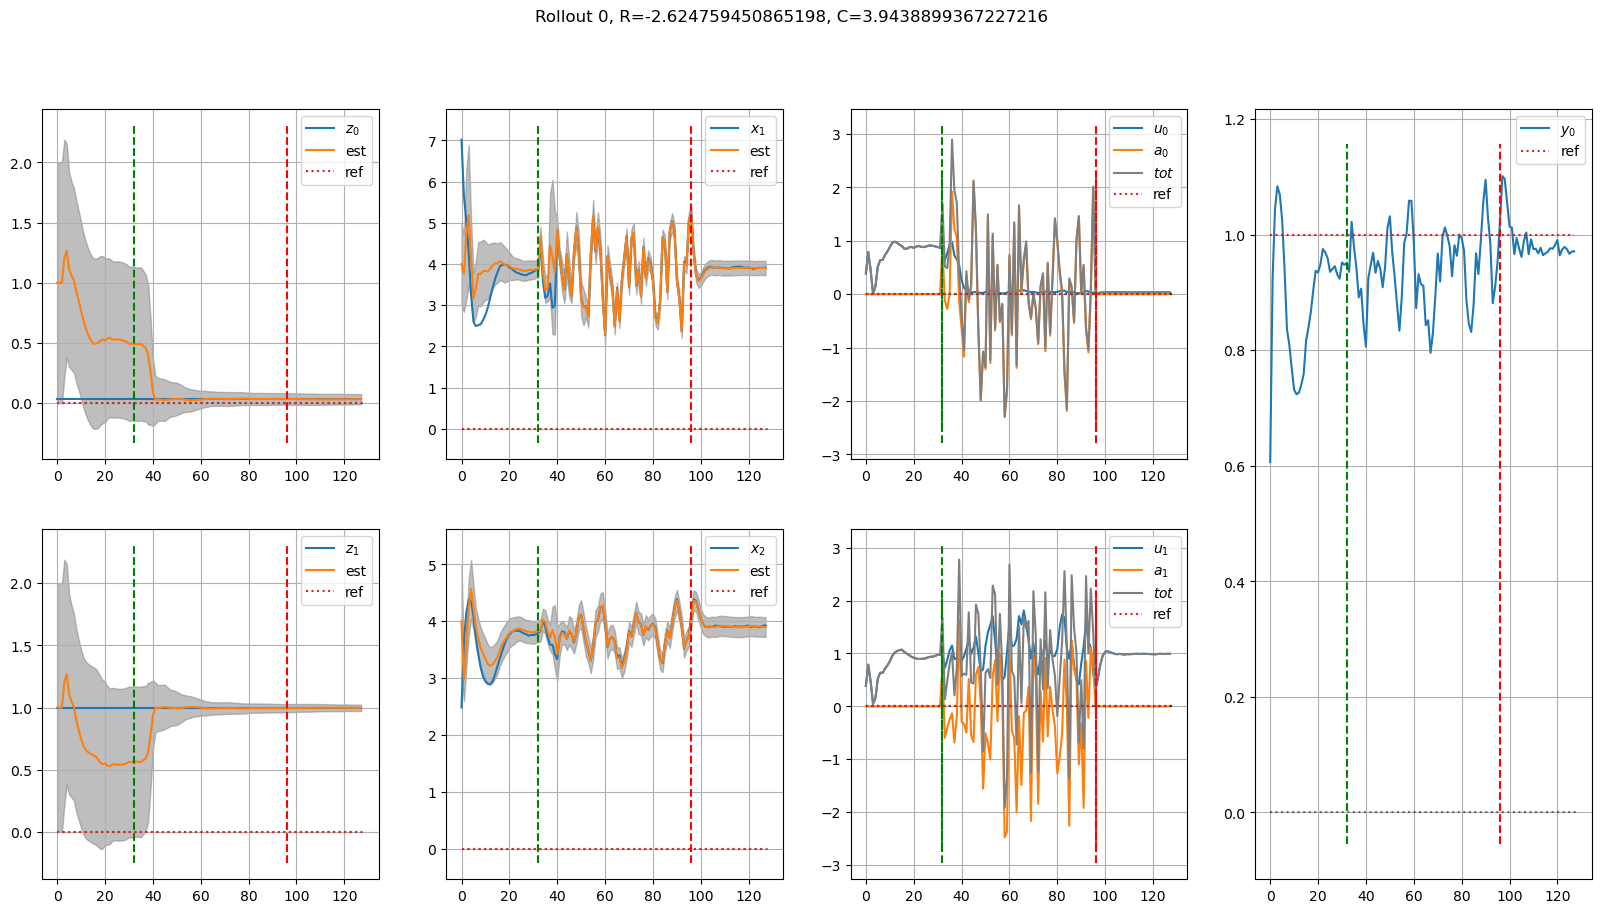

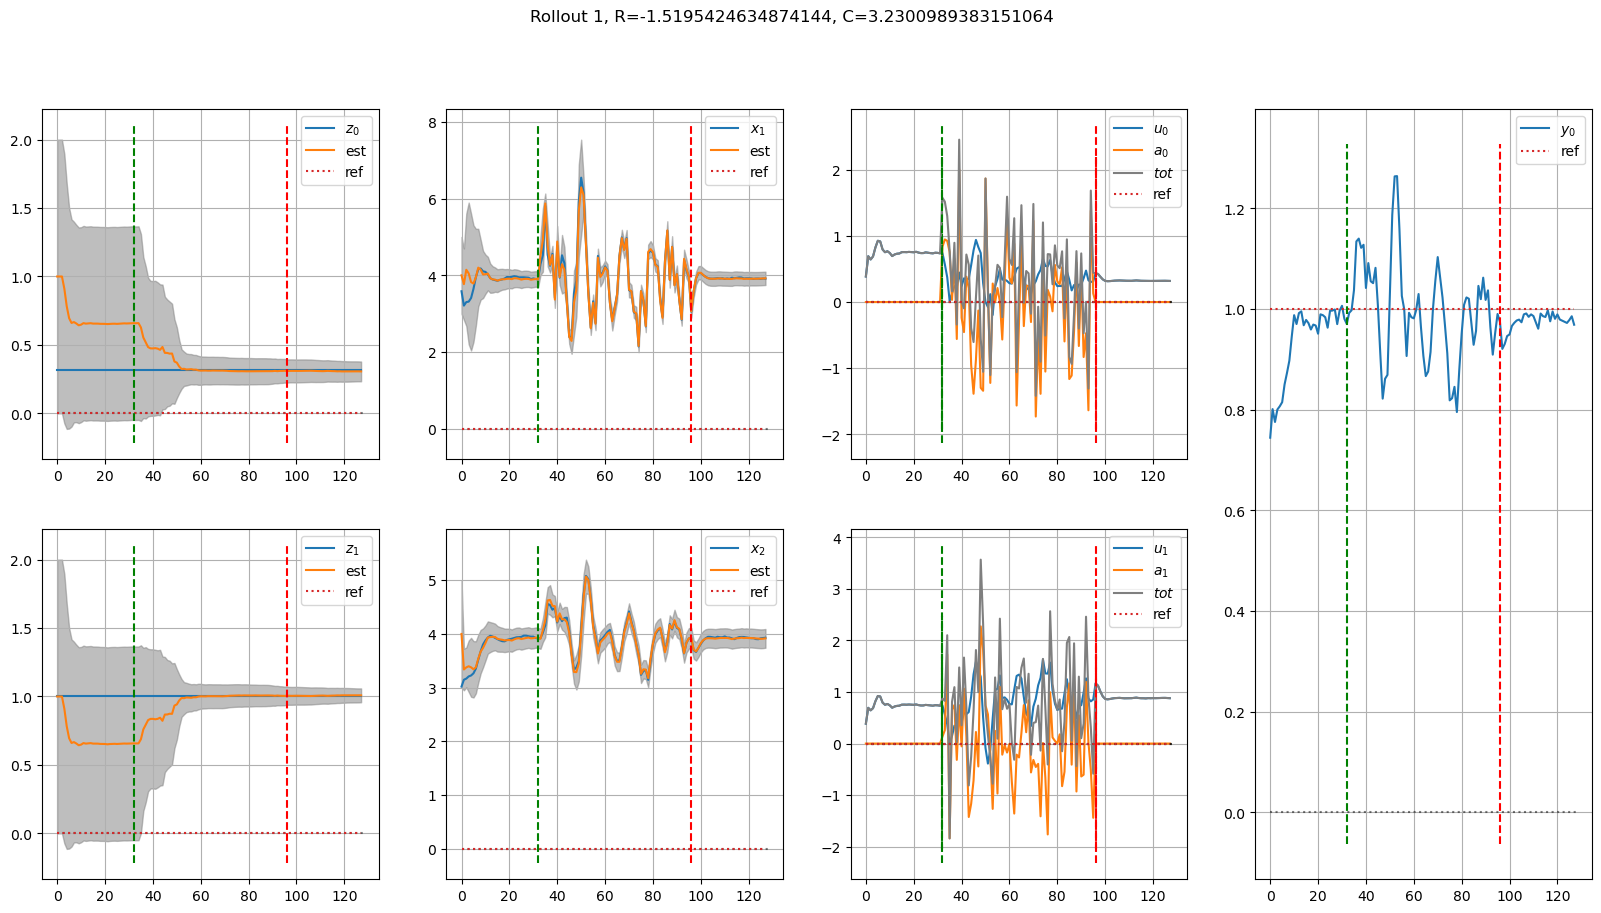

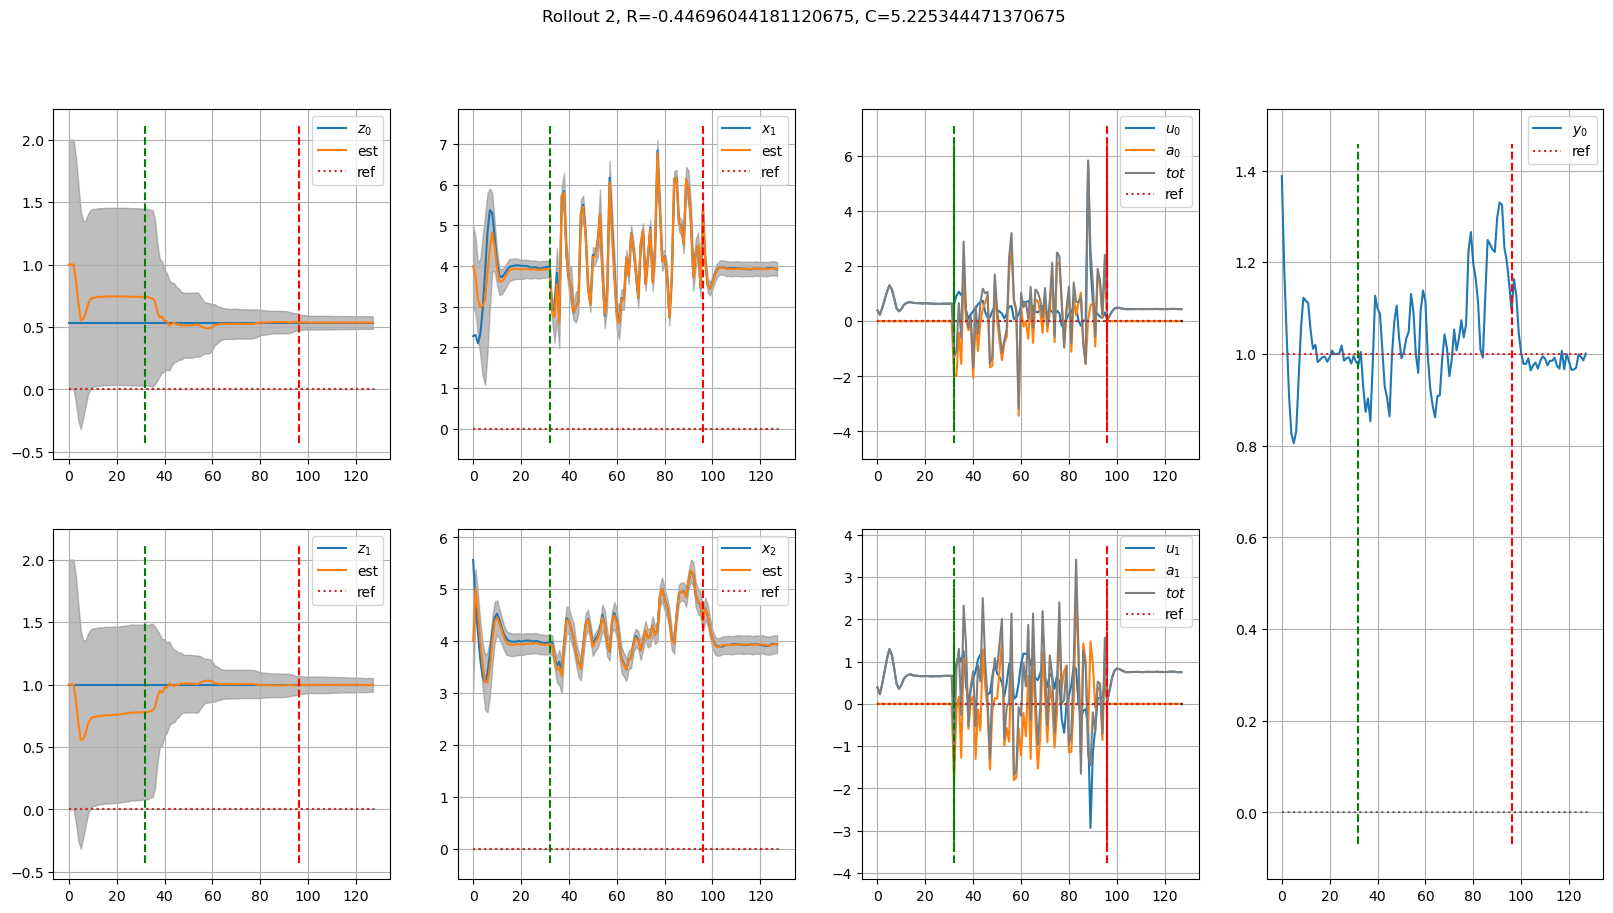

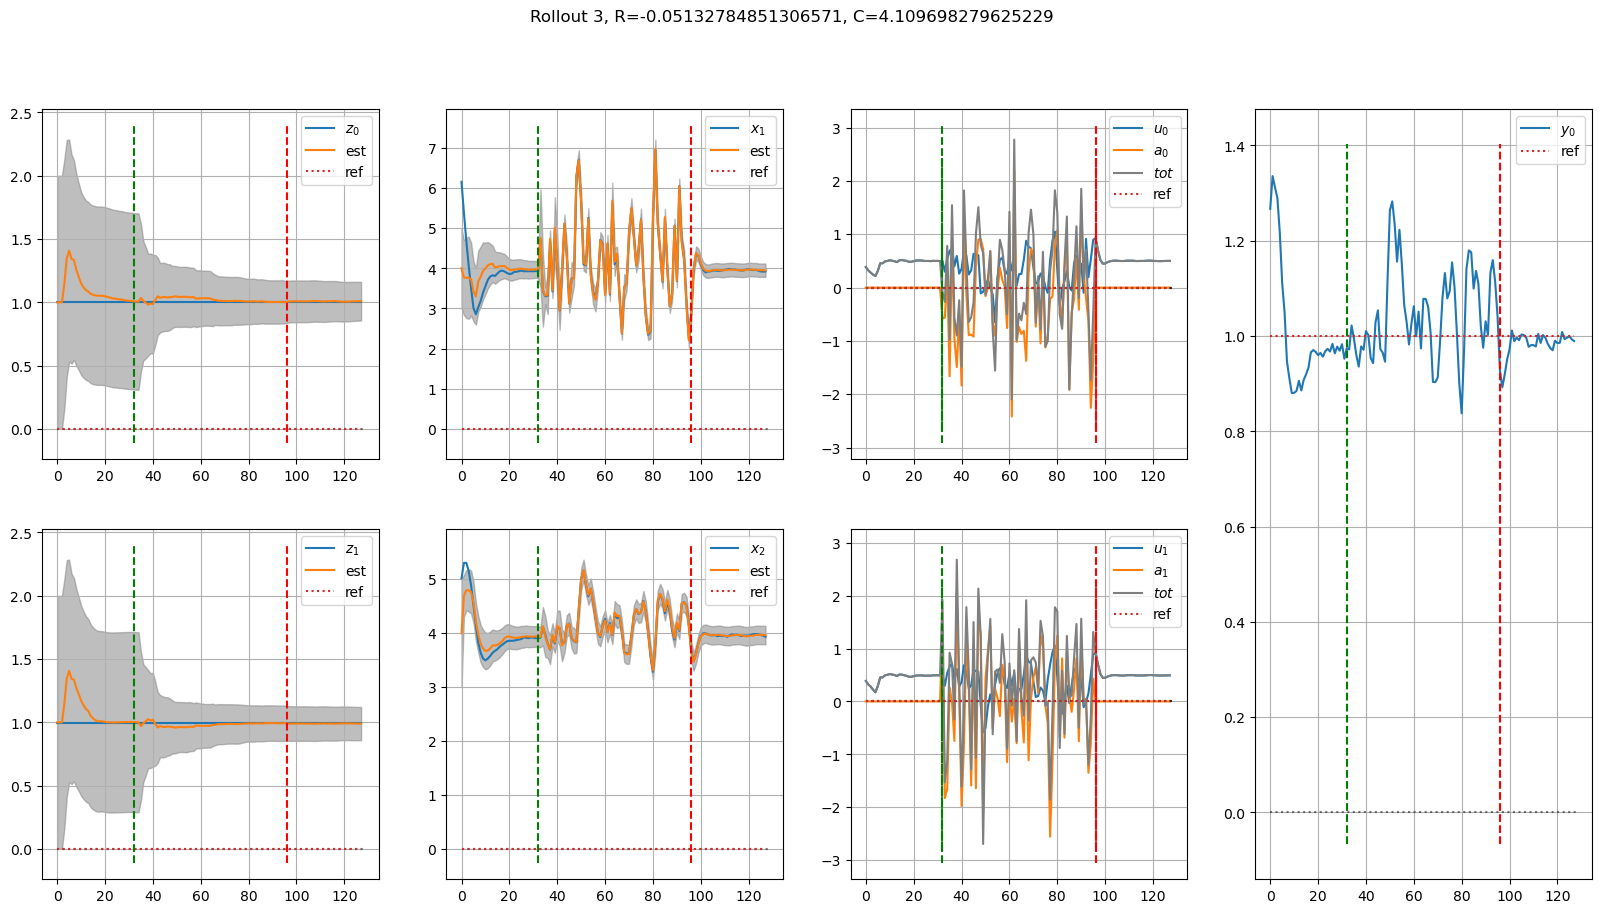

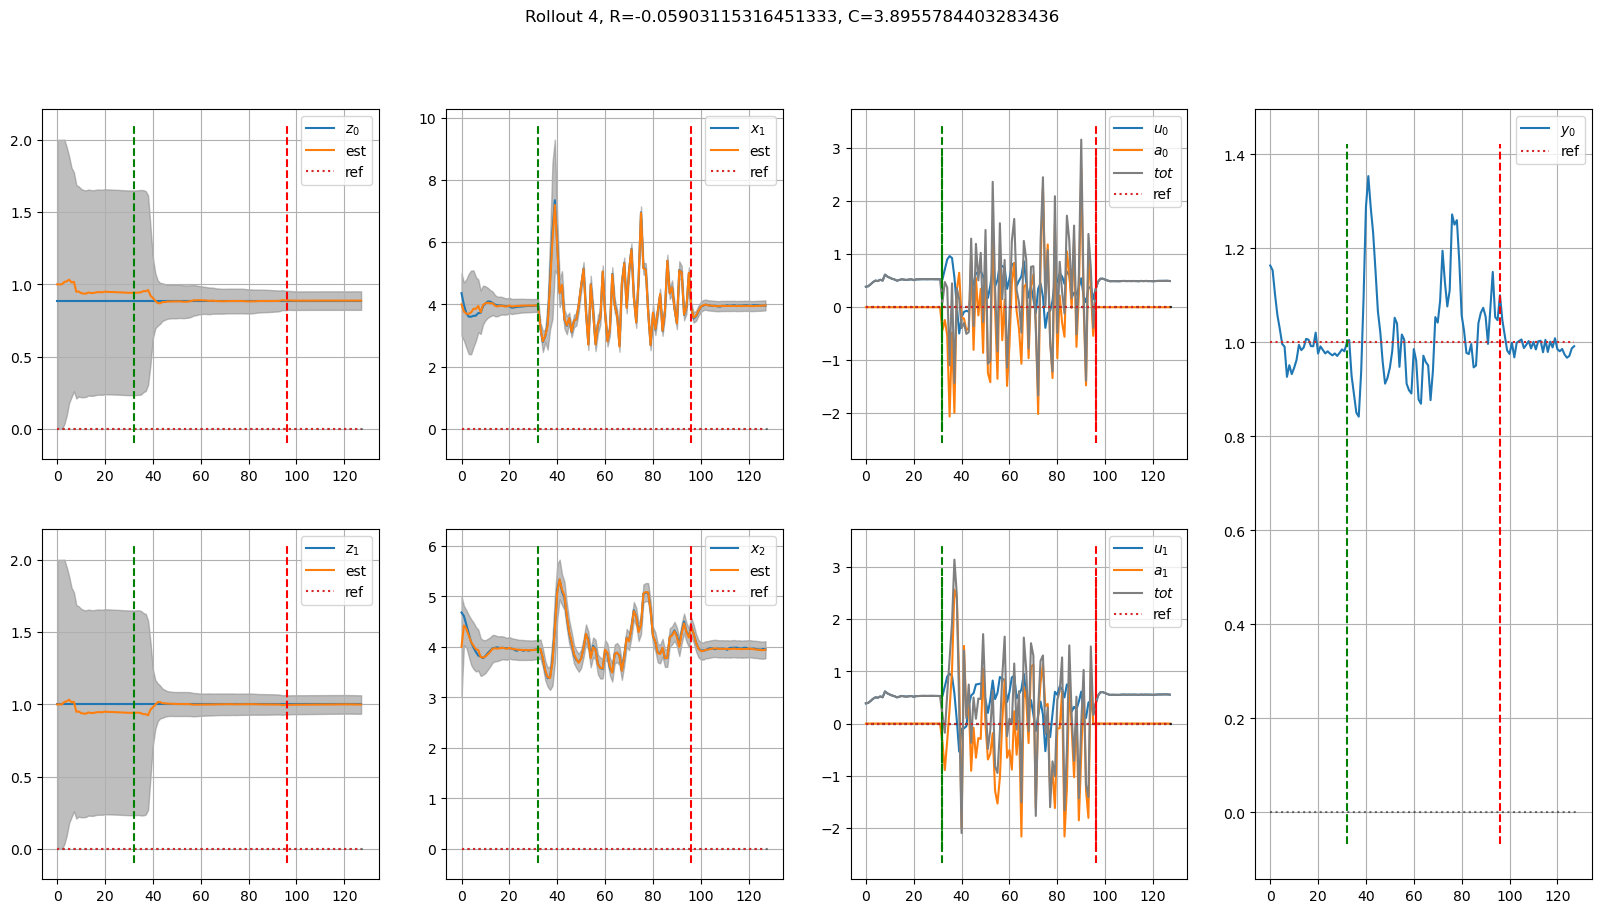

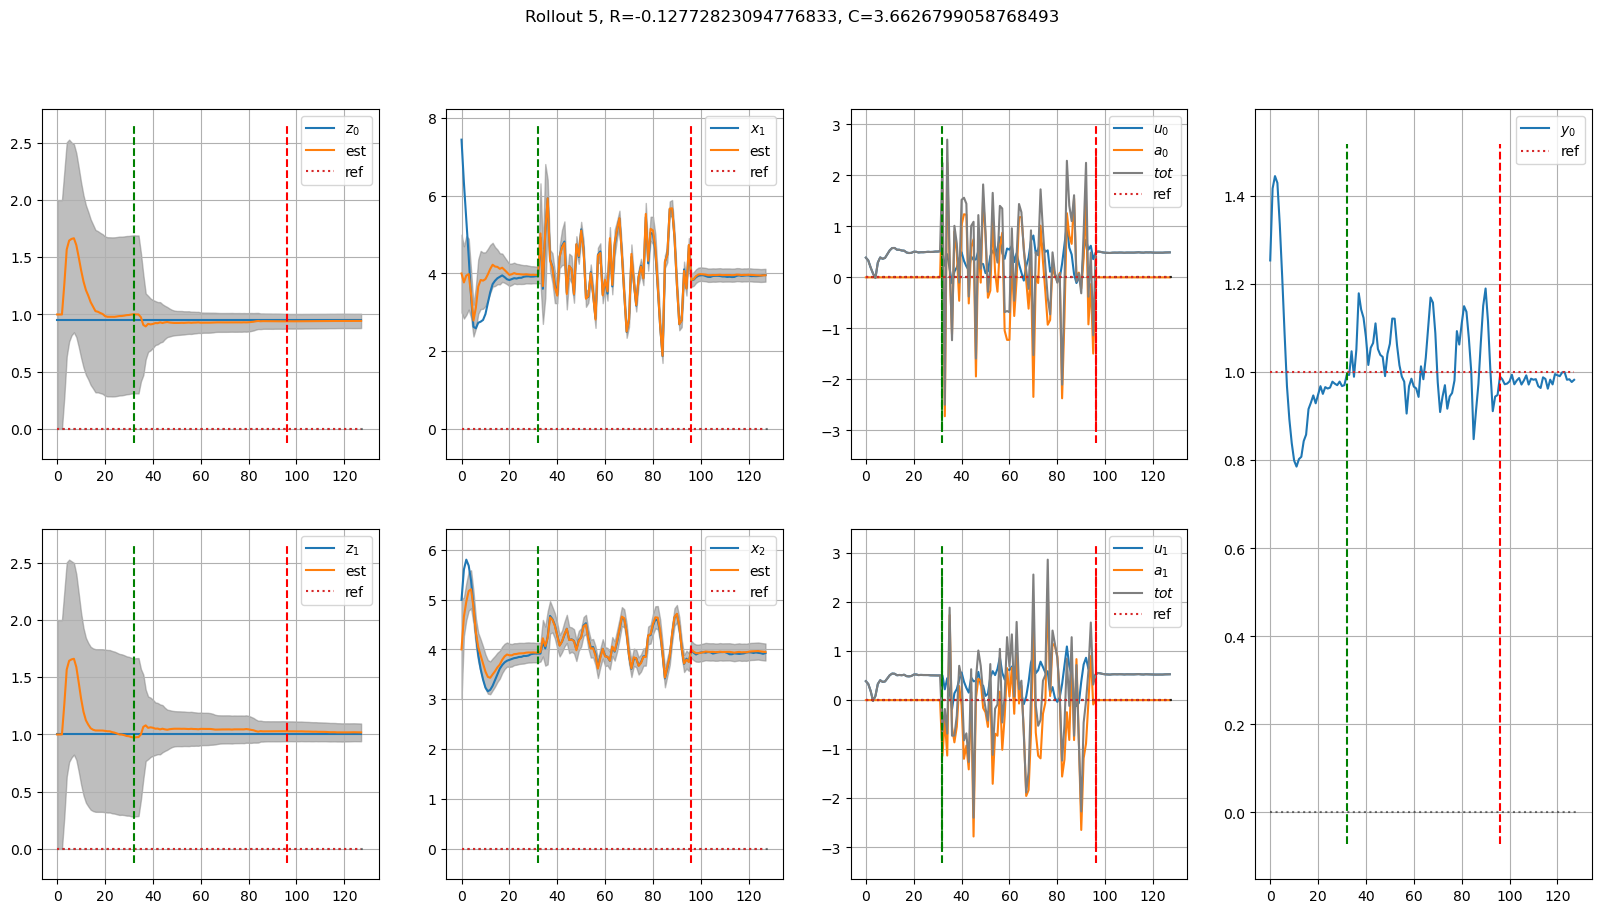

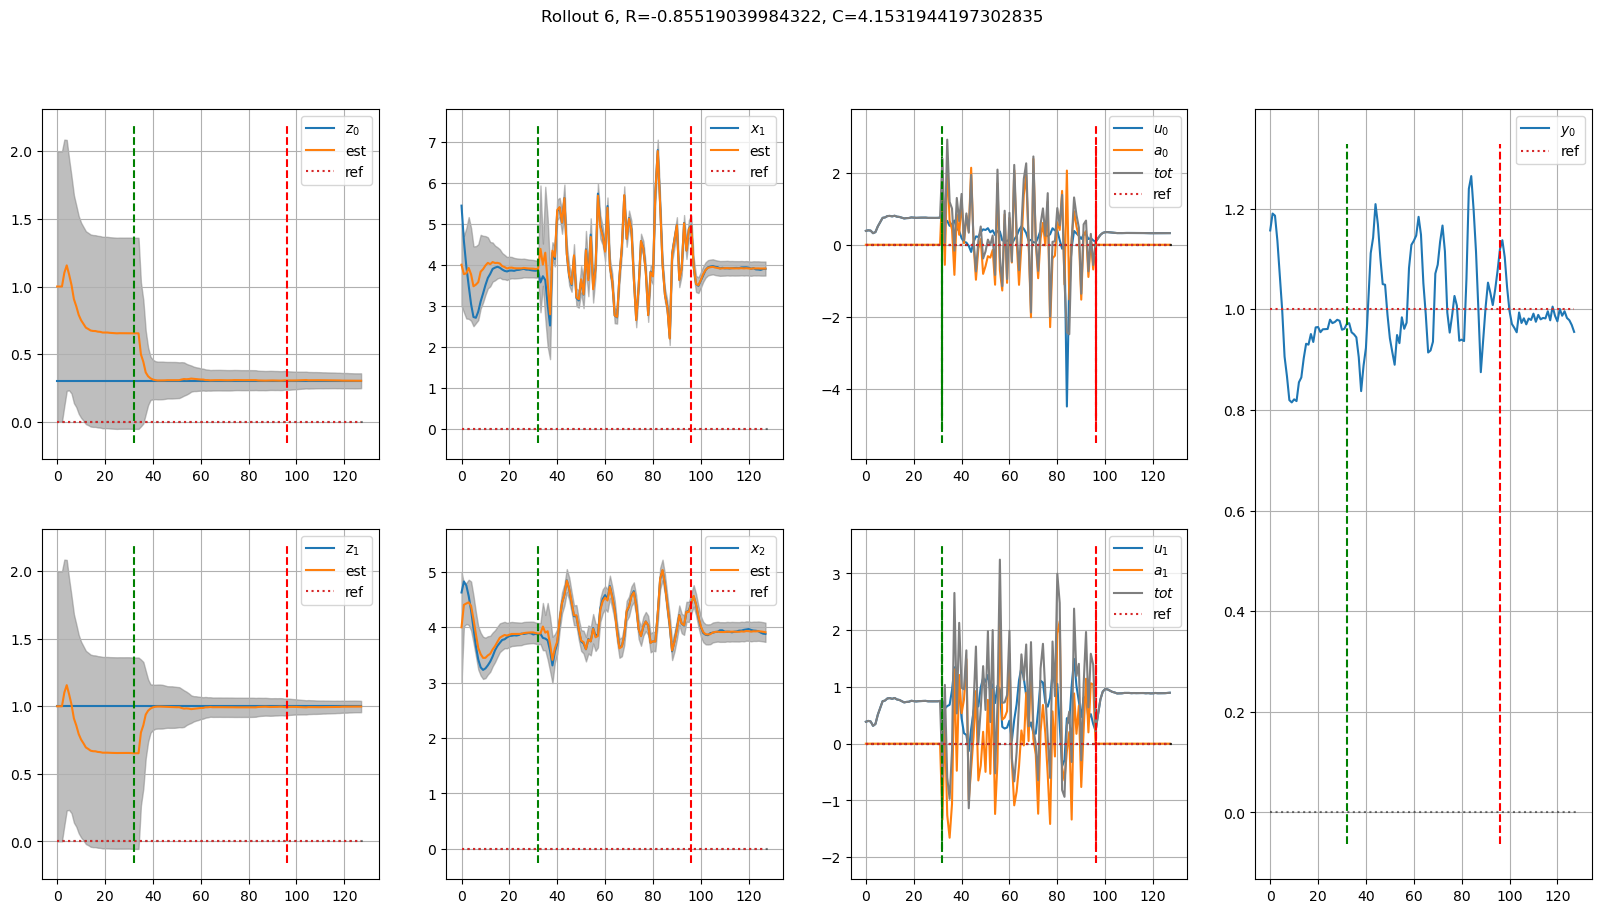

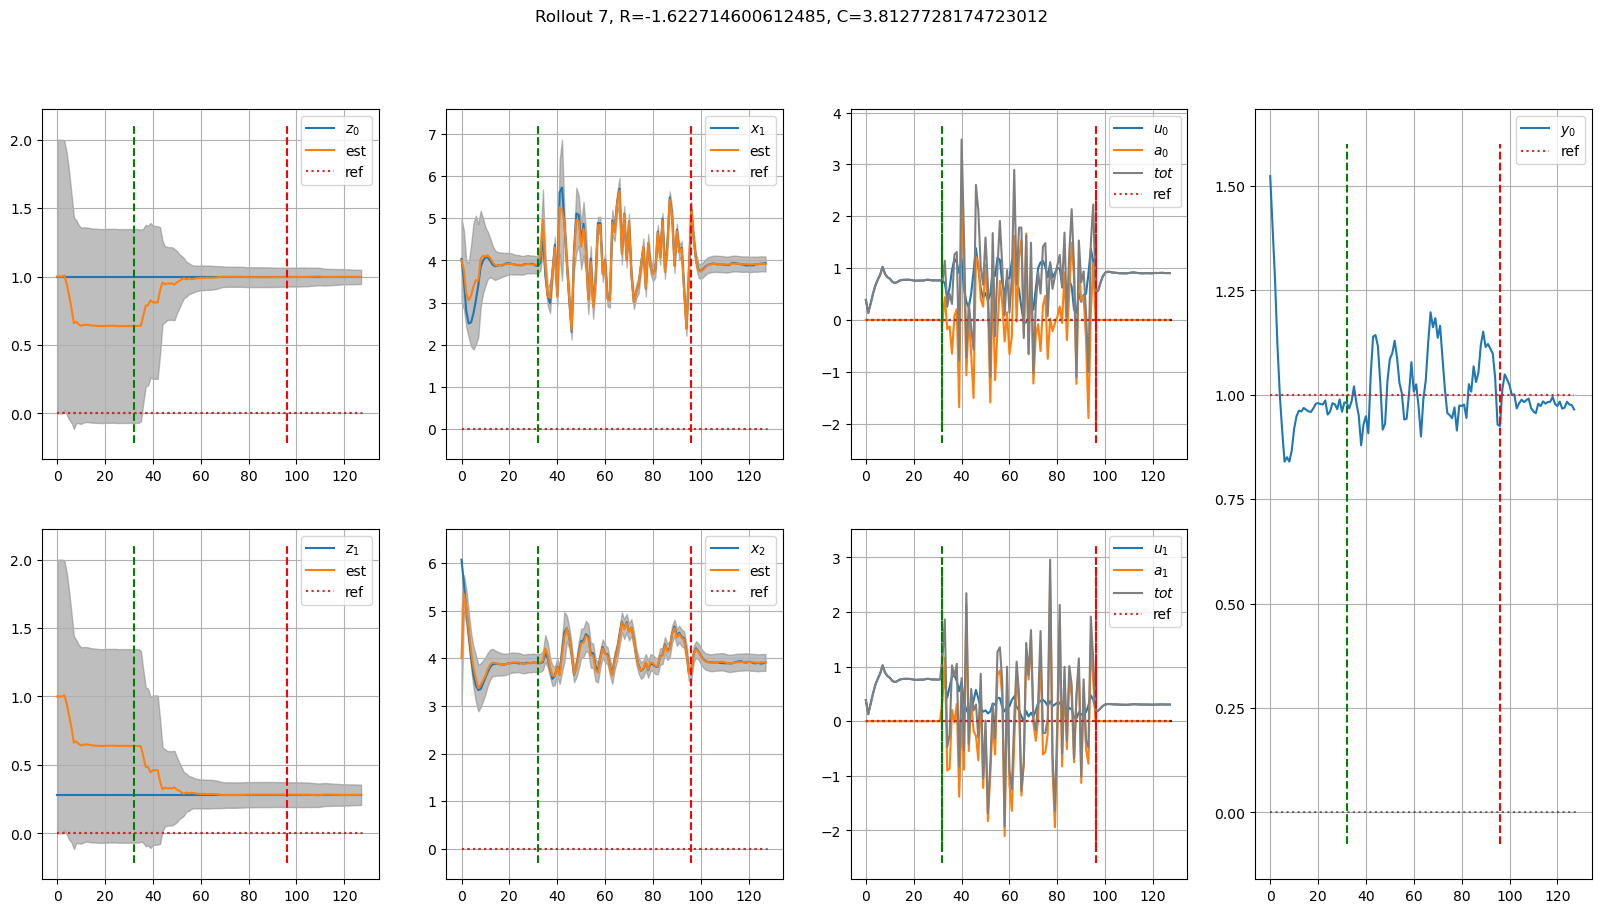

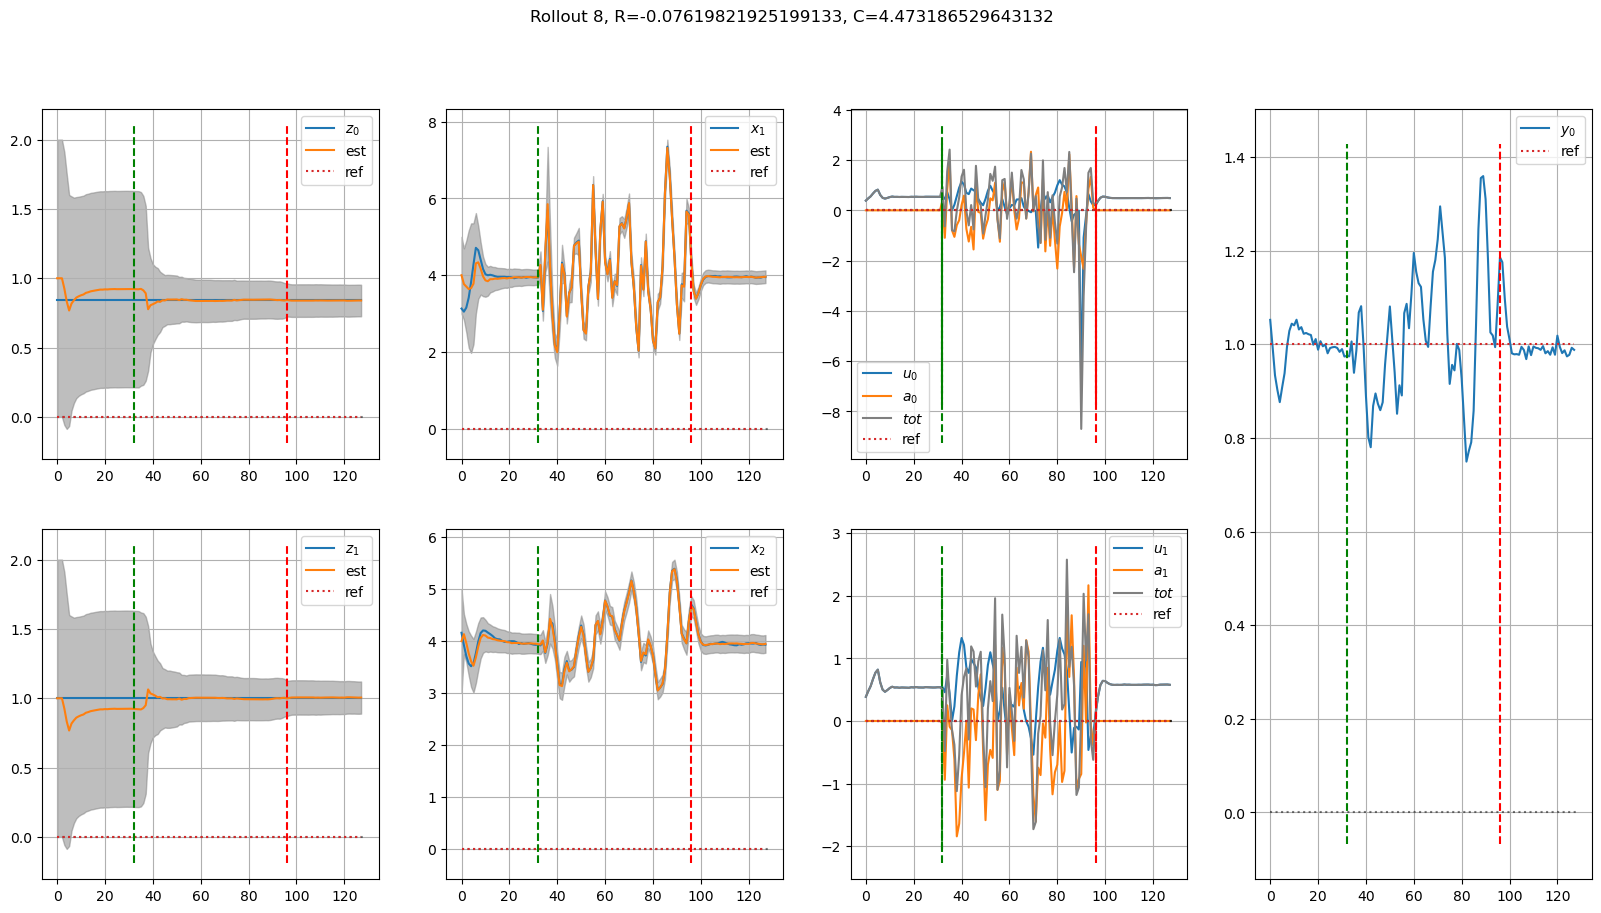

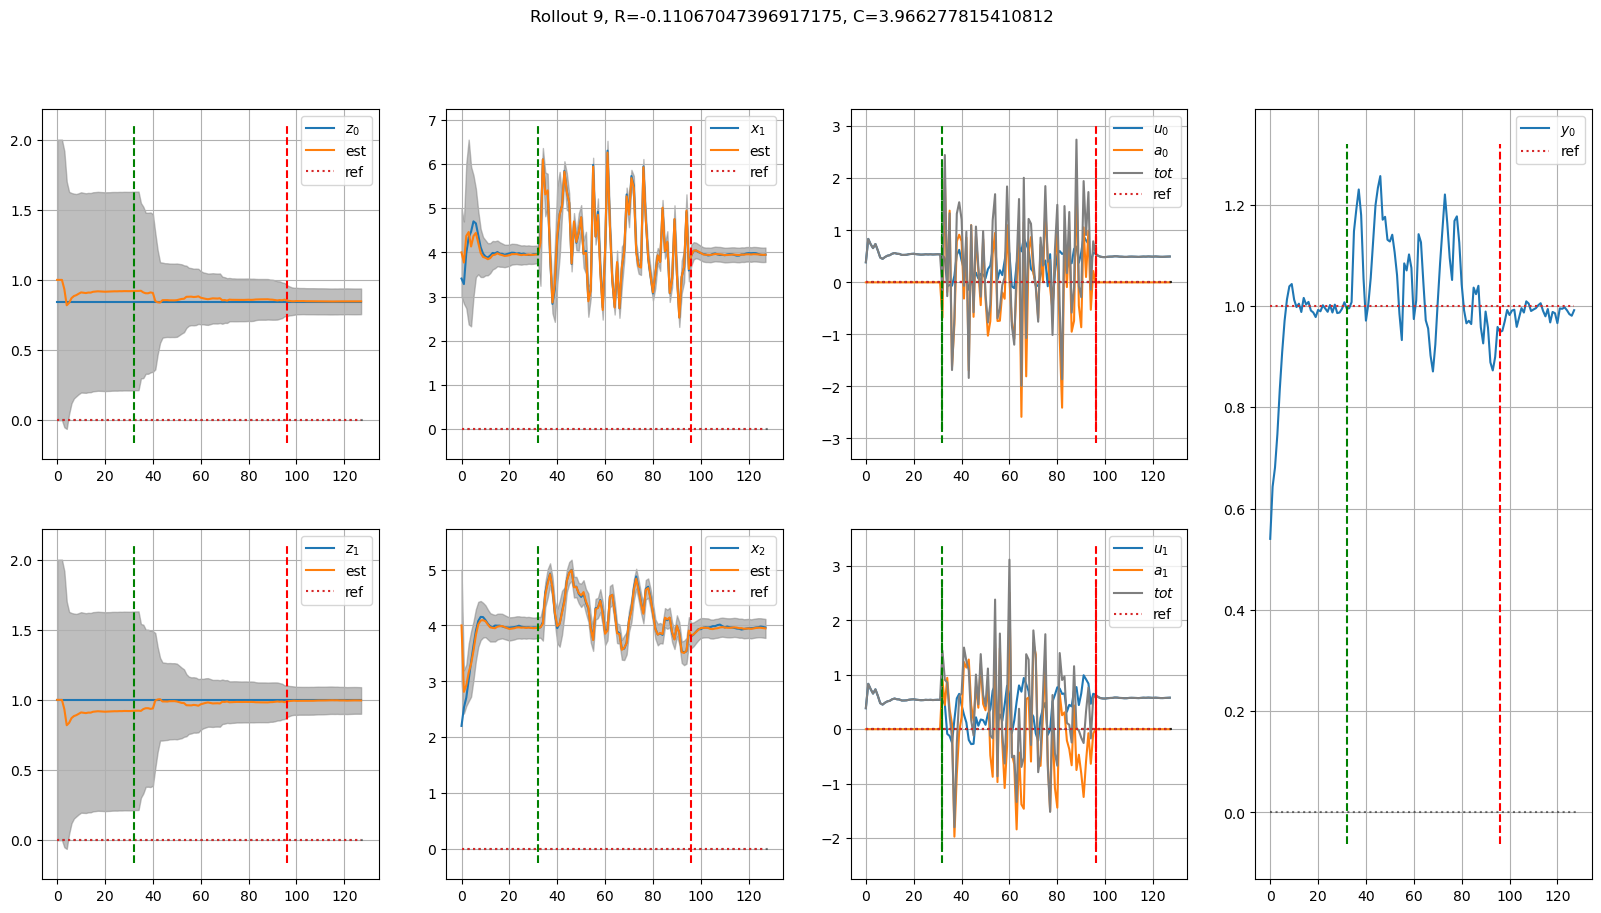

In [4]:
for i in range(10):
    rollout, out = env.rollout(trainer.policy, 128)
    R, _ = get_returns(rollout.r, trainer.discount)
    C, _ = get_returns(rollout.c, trainer.discount)
    env.render(out, title=f"Rollout {i}, R={R}, C={C}")

# Train

In [5]:
logger = trainer.train(epochs=1000, episode_length=128)
nnx.display(trainer)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [03:35<00:00,  4.63it/s, V=-1.84, c=0.037, r=-.00892]   


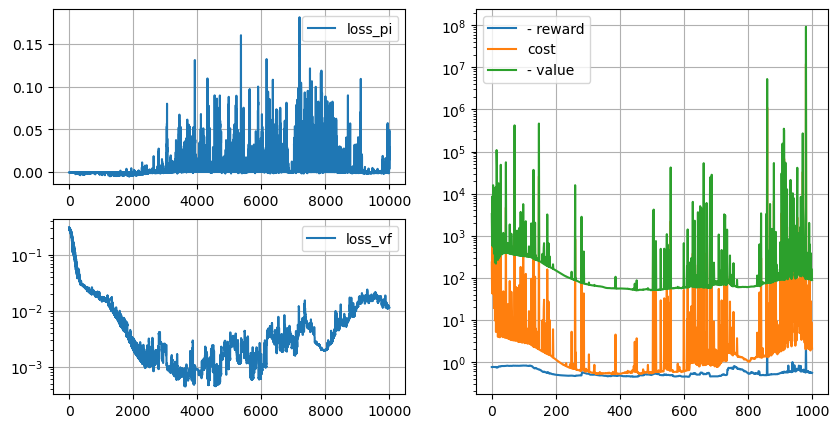

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.plot(logger["loss_pi"], label='loss_pi') 
plt.legend()
plt.grid()
plt.subplot(2, 2, 3)
plt.semilogy(logger["loss_vf"], label='loss_vf')
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
batch_returns = jax.vmap(jax.vmap(lambda x: get_returns(x, trainer.discount)[0]))
plt.semilogy(-batch_returns(logger["reward"]).mean(axis=-1), label='- reward')
plt.semilogy(batch_returns(logger["cost"]).mean(axis=-1), label='cost')
plt.semilogy(-batch_returns(logger["V"]).mean(axis=-1), label='- value')
plt.legend()
plt.grid()
plt.show()

# Trained Policy

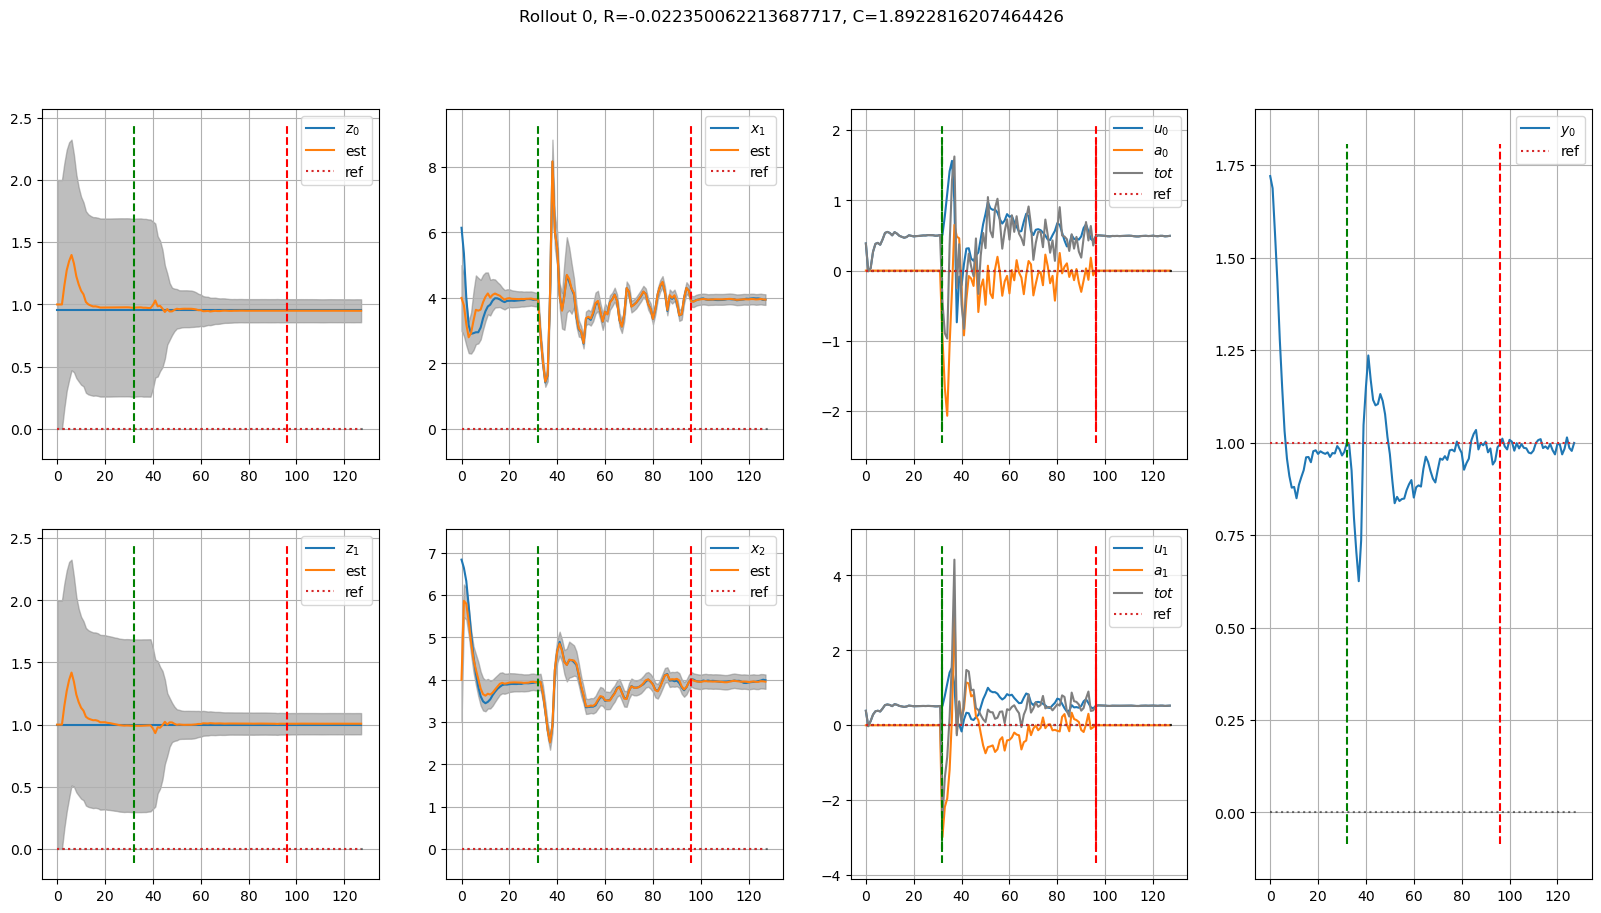

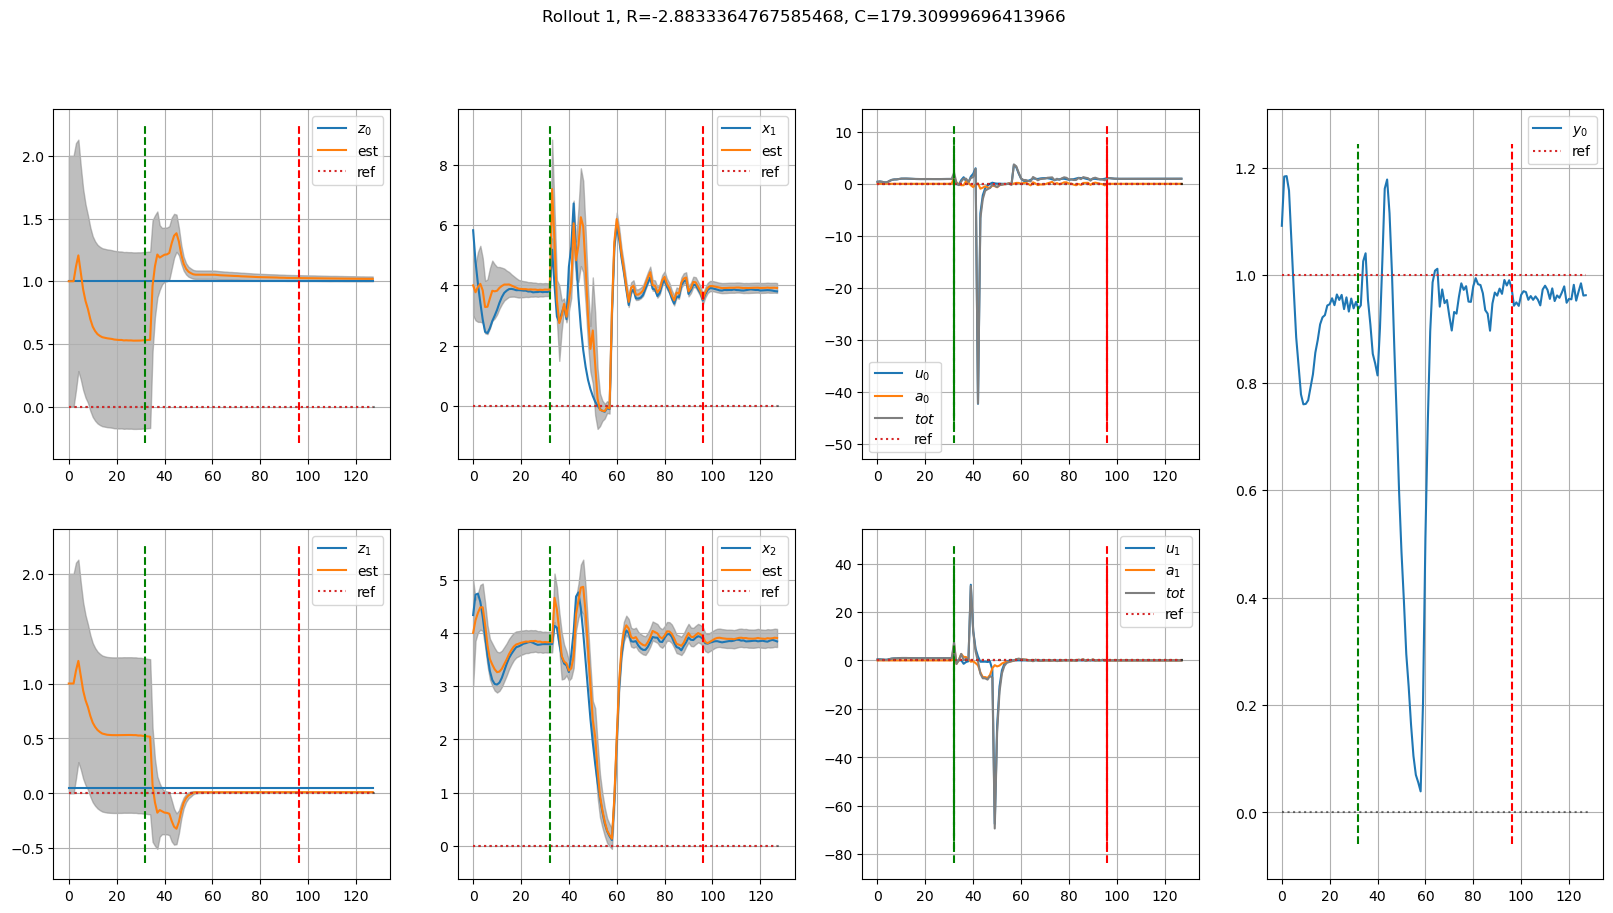

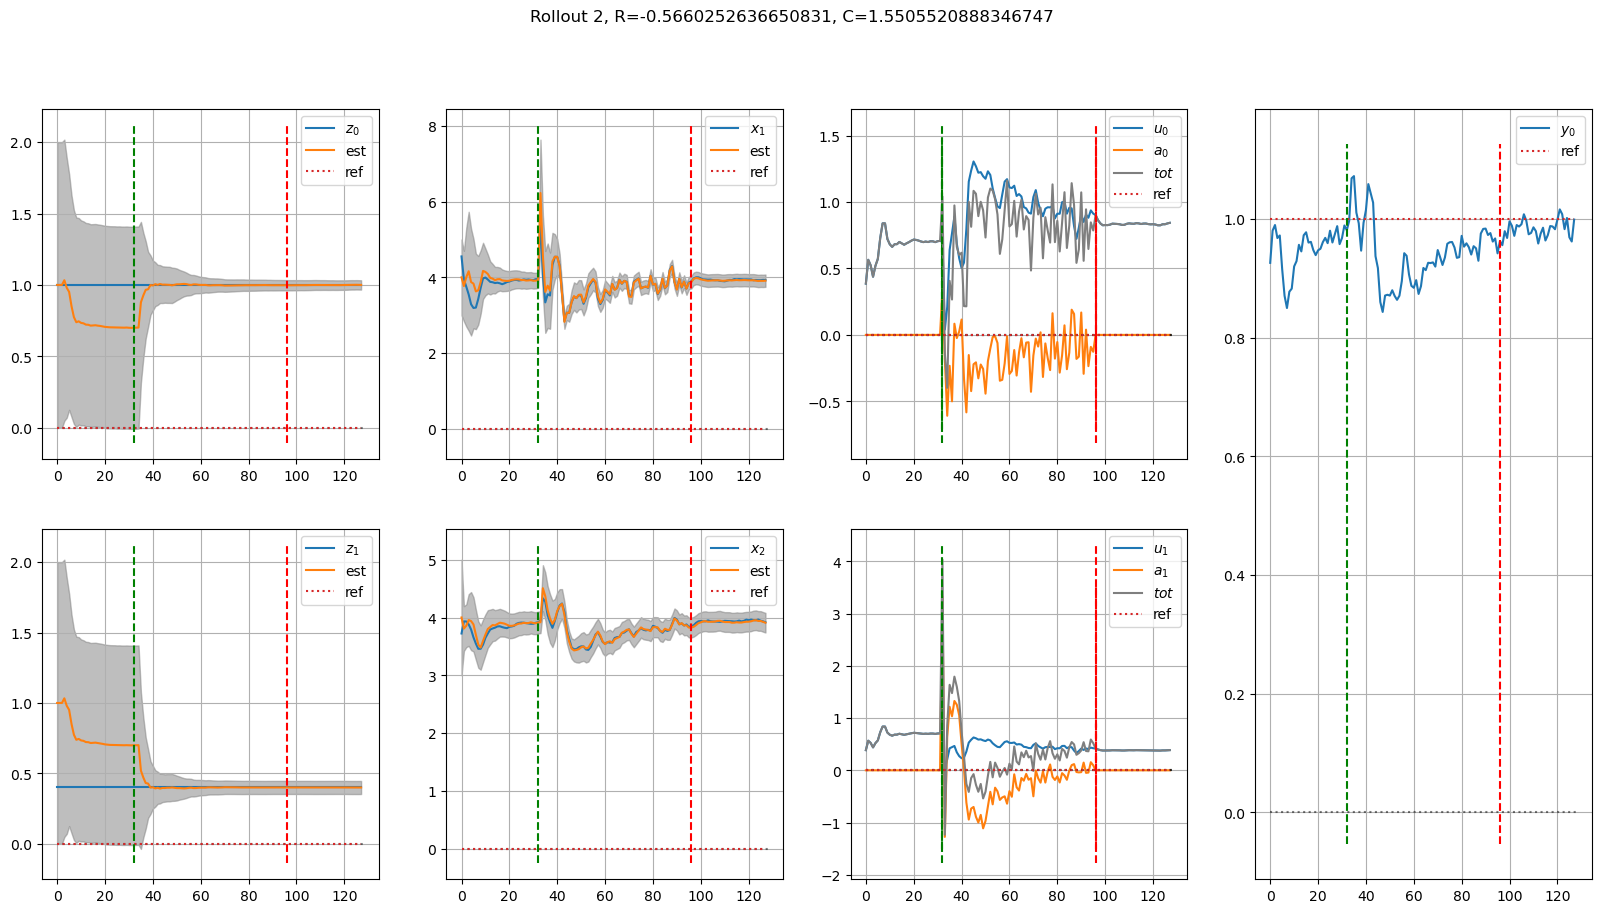

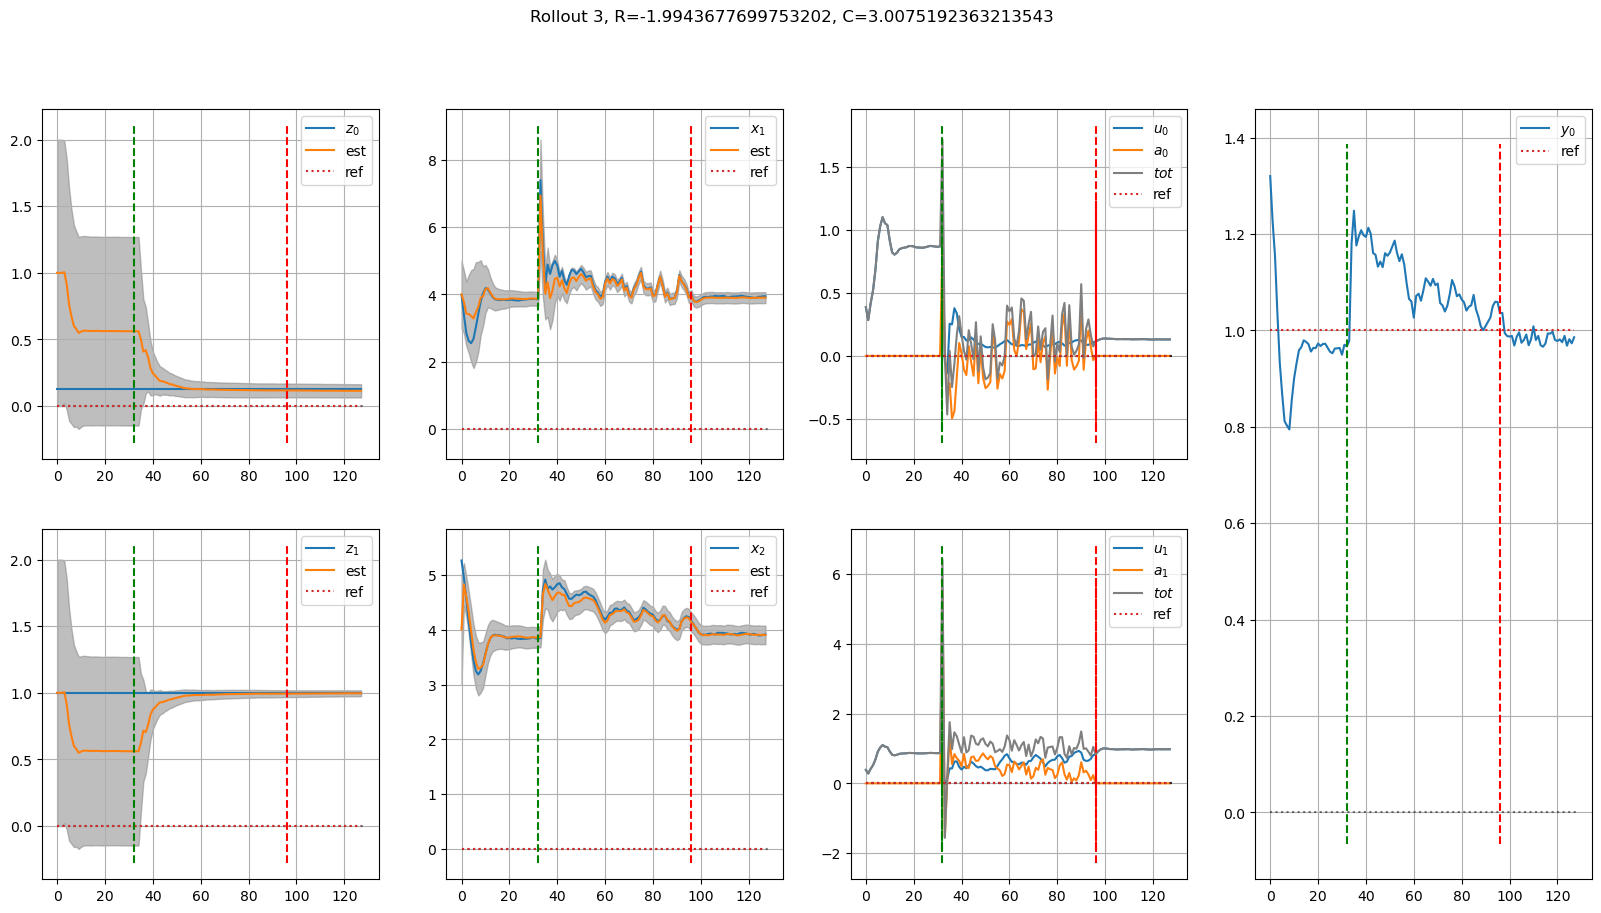

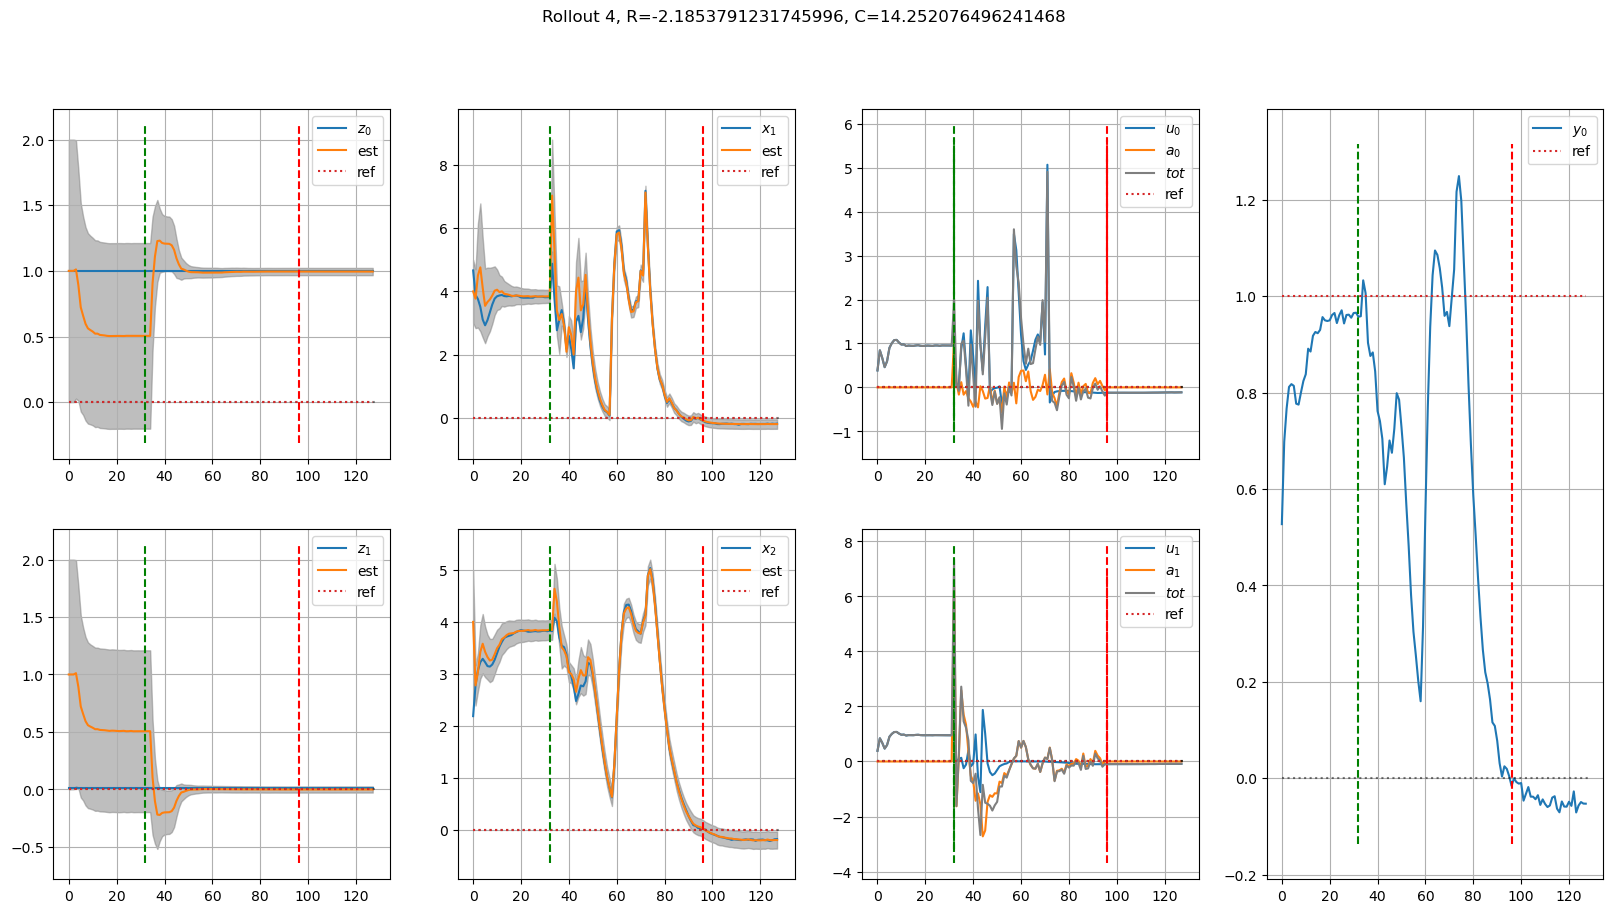

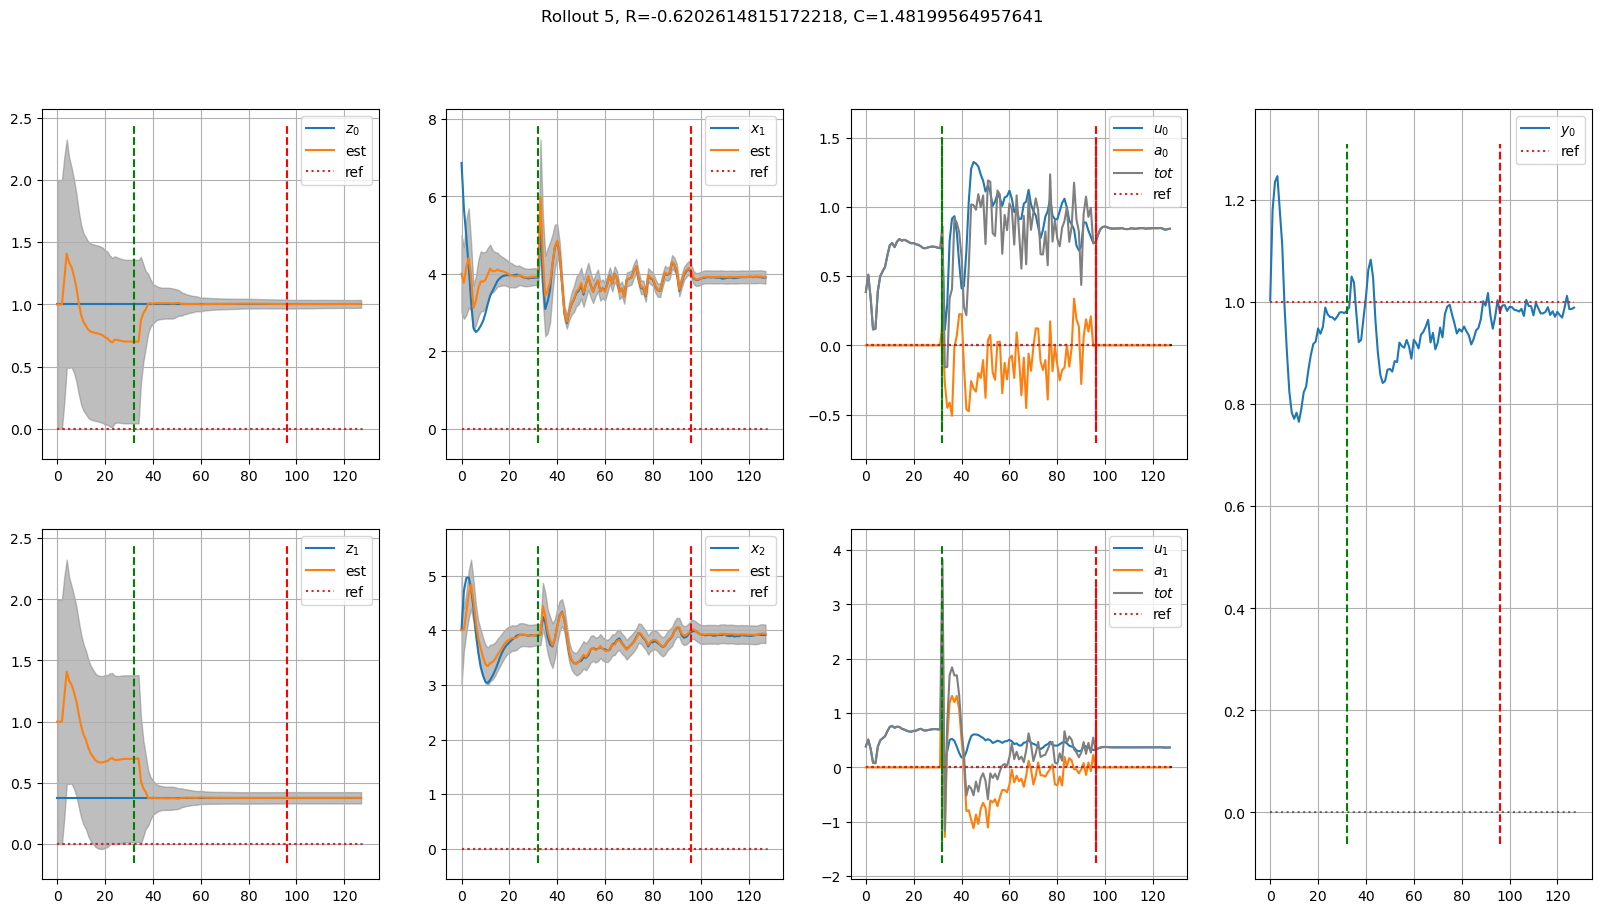

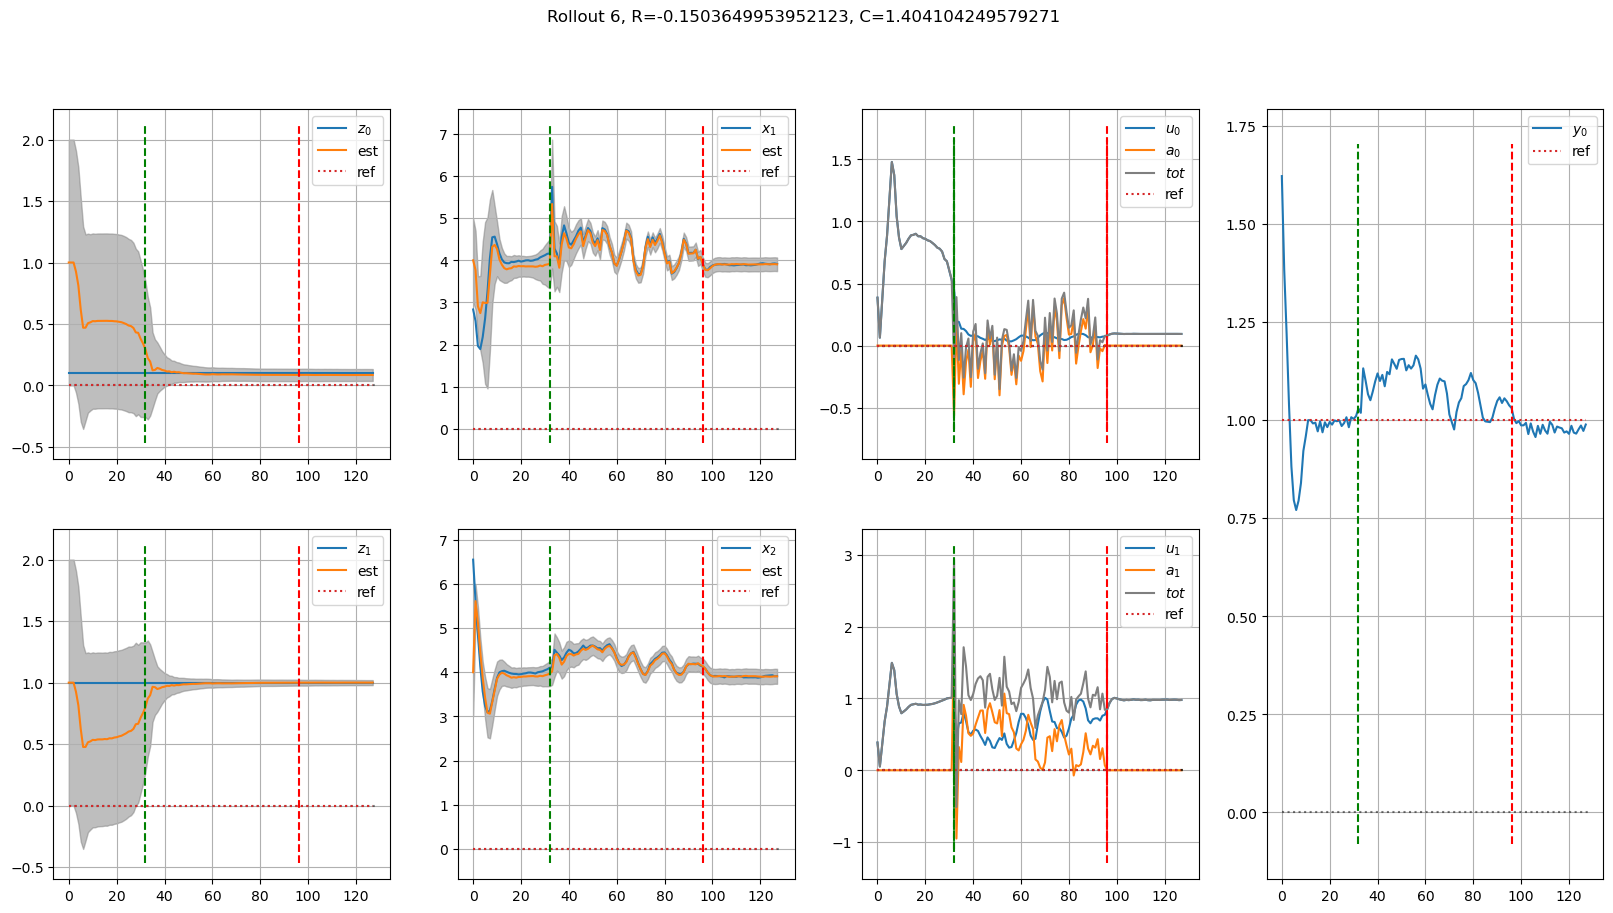

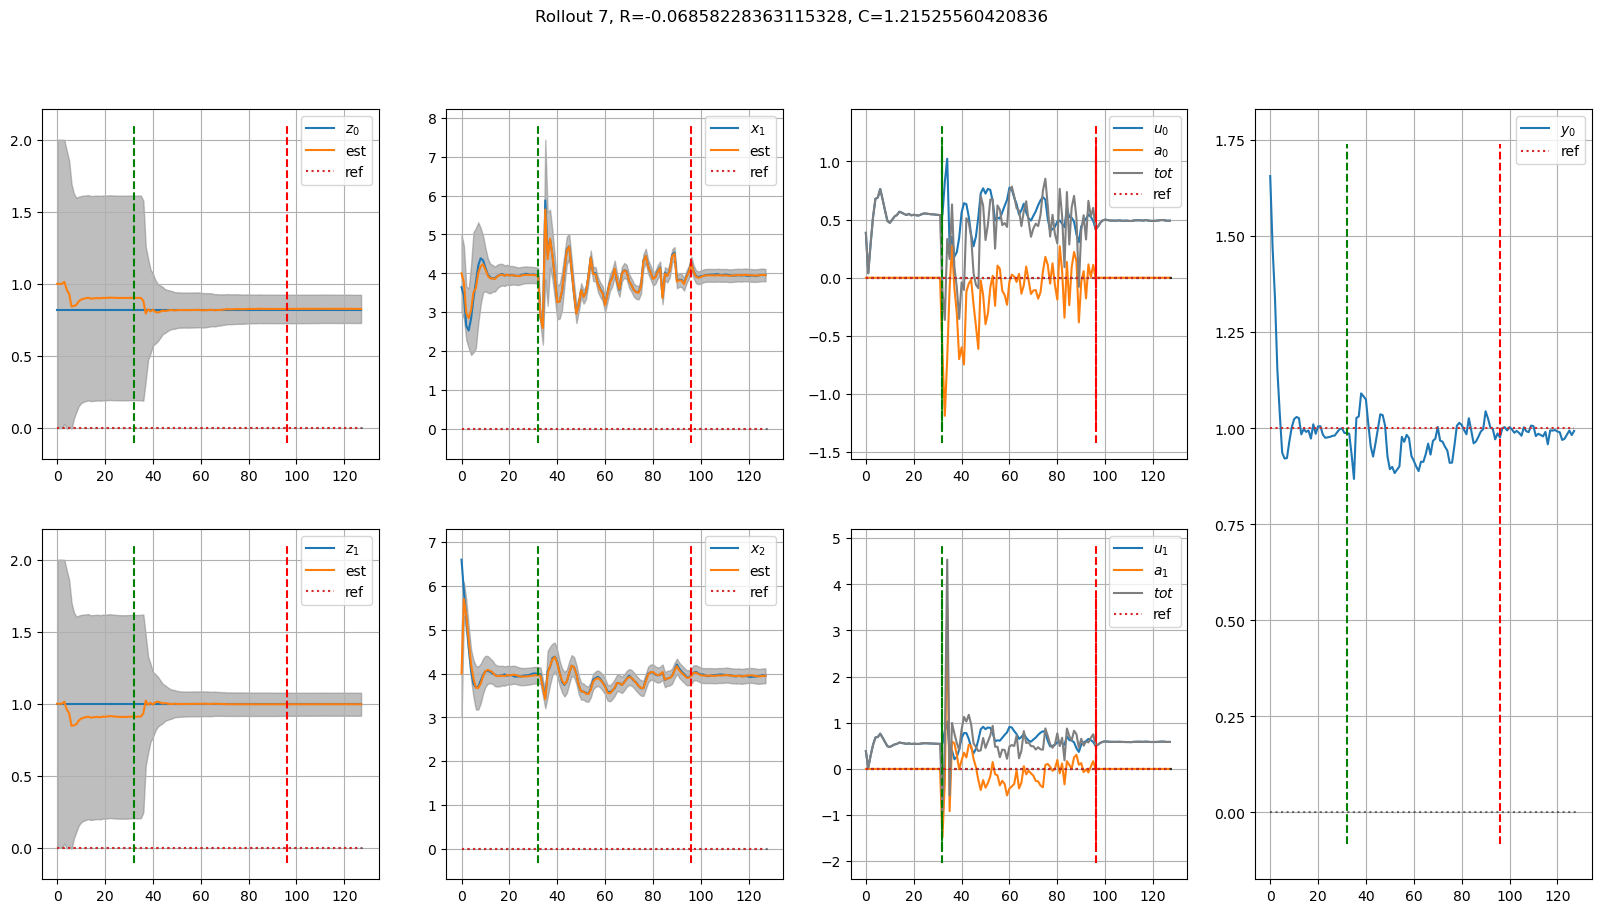

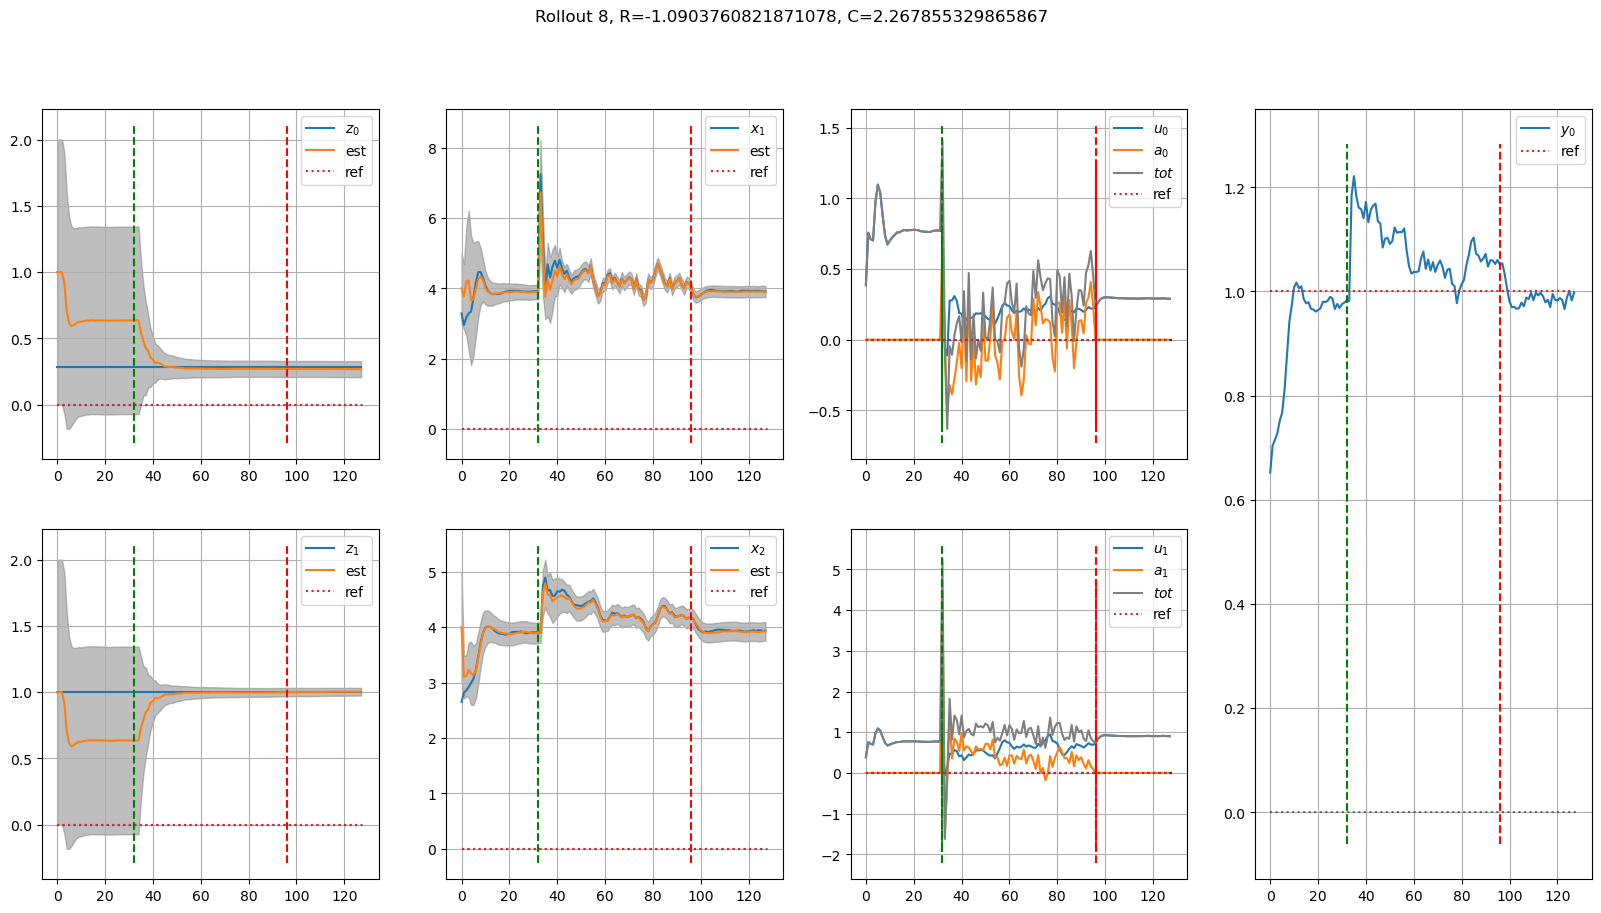

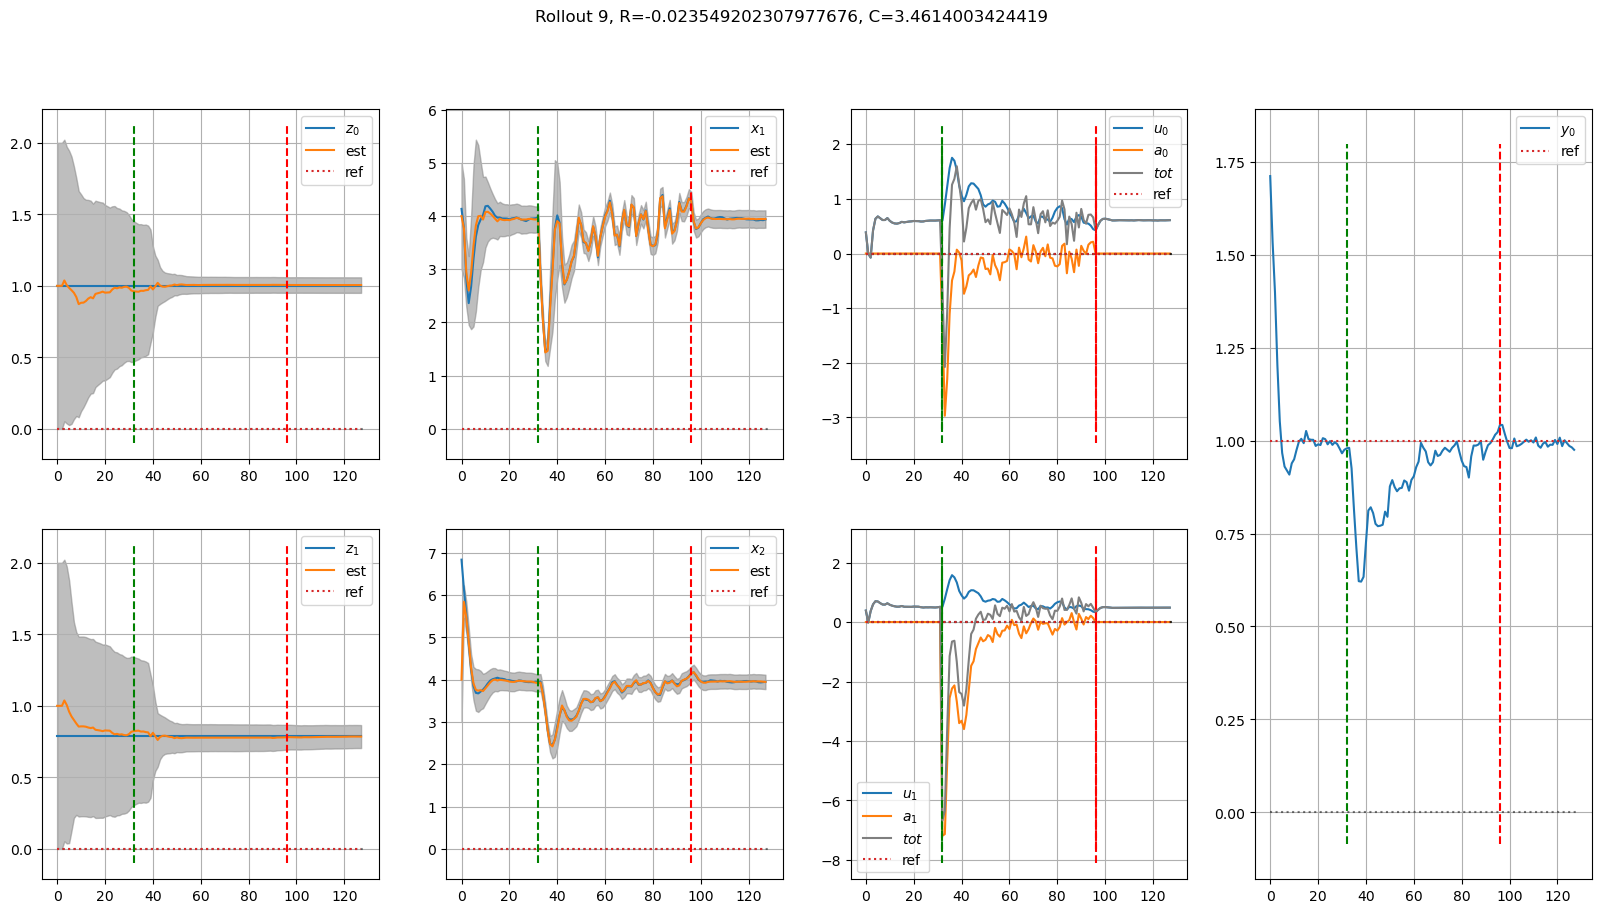

In [7]:
for i in range(10):
    rollout, out = env.rollout(trainer.policy, 128)
    R, _ = get_returns(rollout.r, trainer.discount)
    C, _ = get_returns(rollout.c, trainer.discount)
    env.render(out, title=f"Rollout {i}, R={R}, C={C}")

# Trained Deterministic

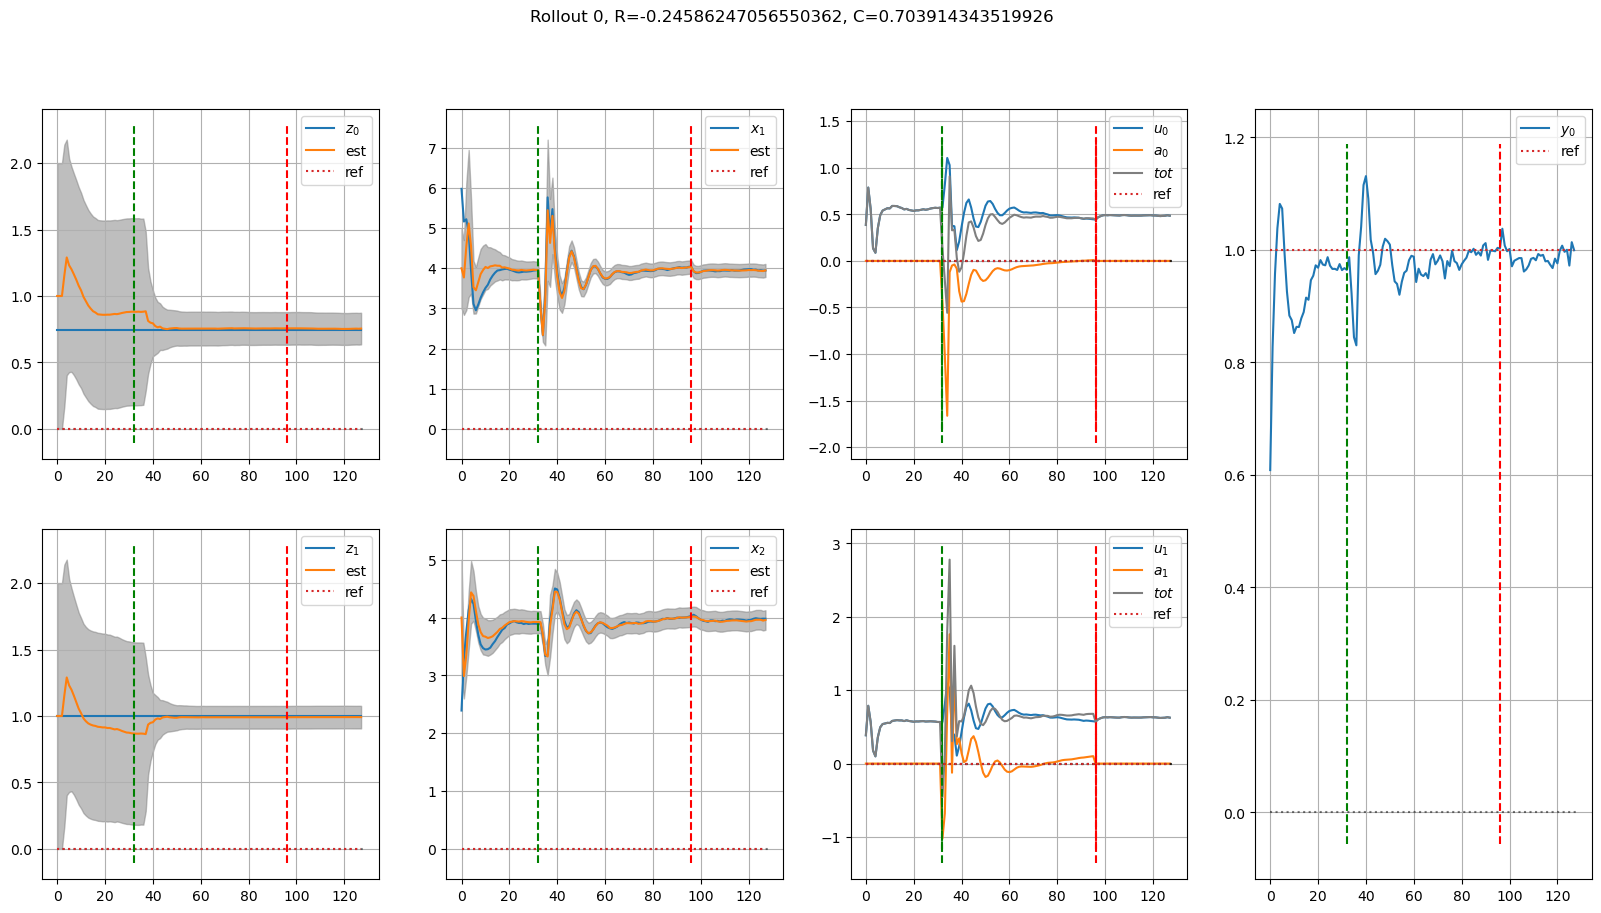

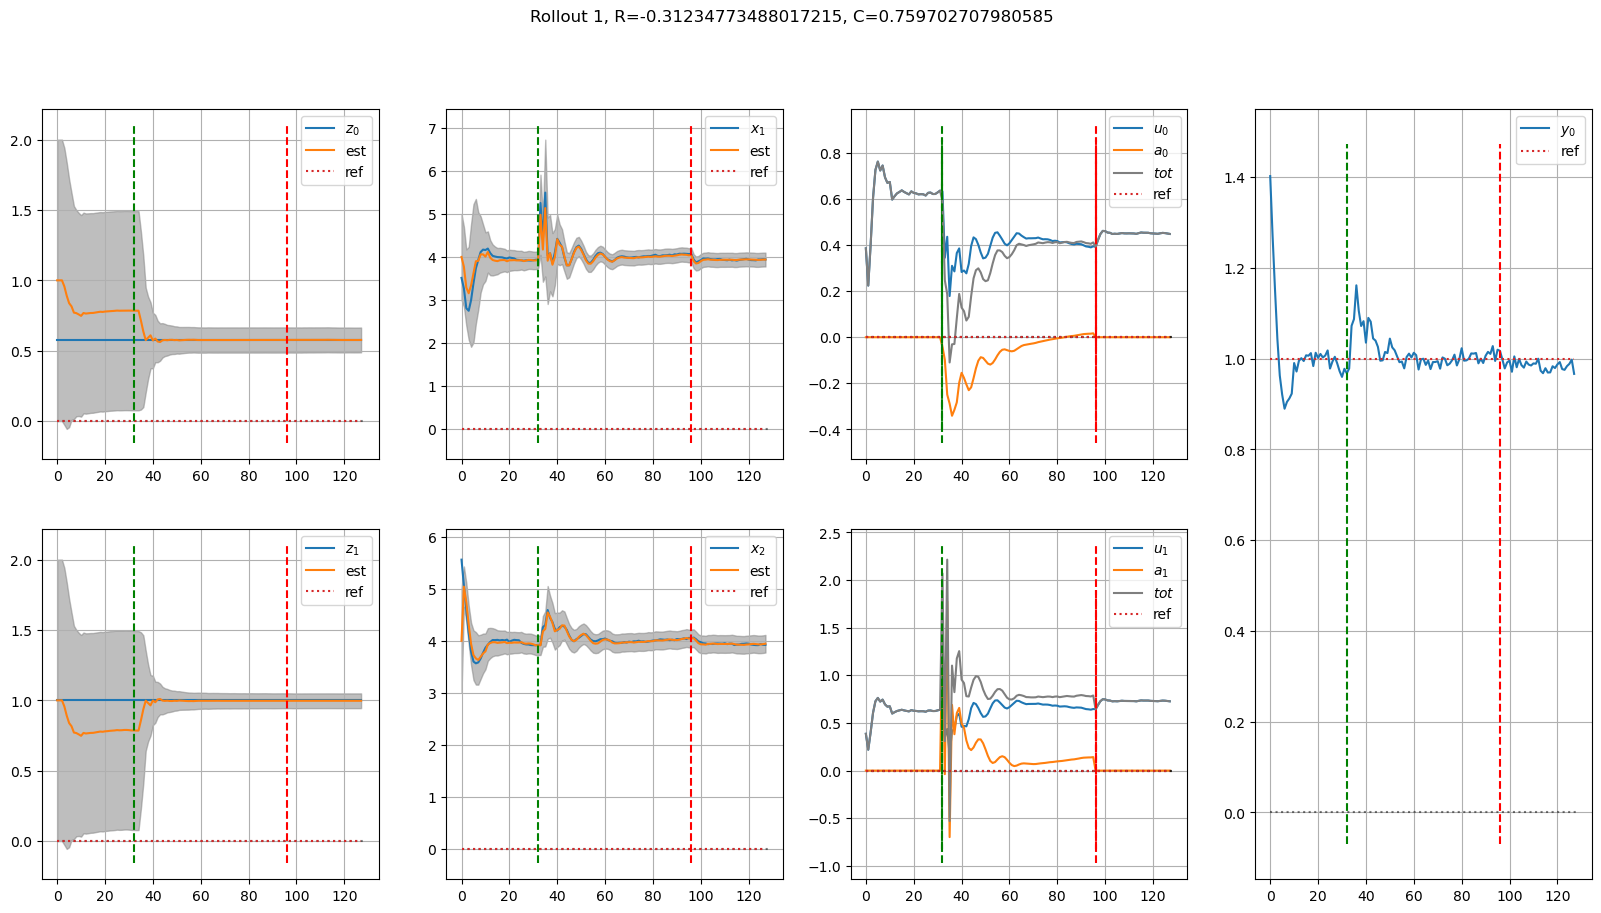

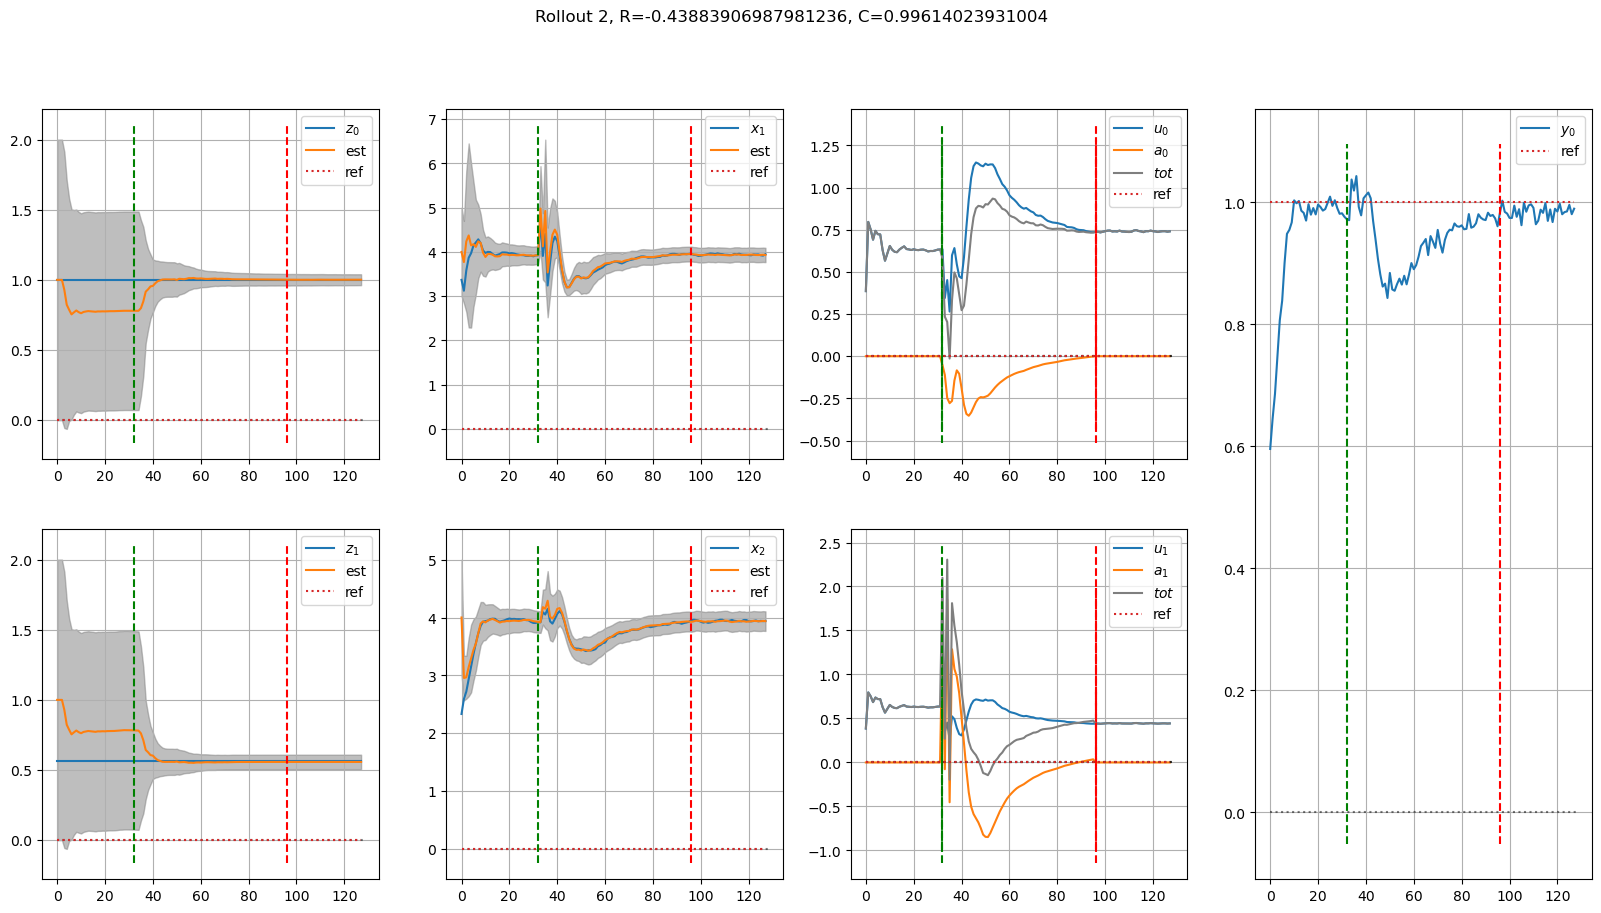

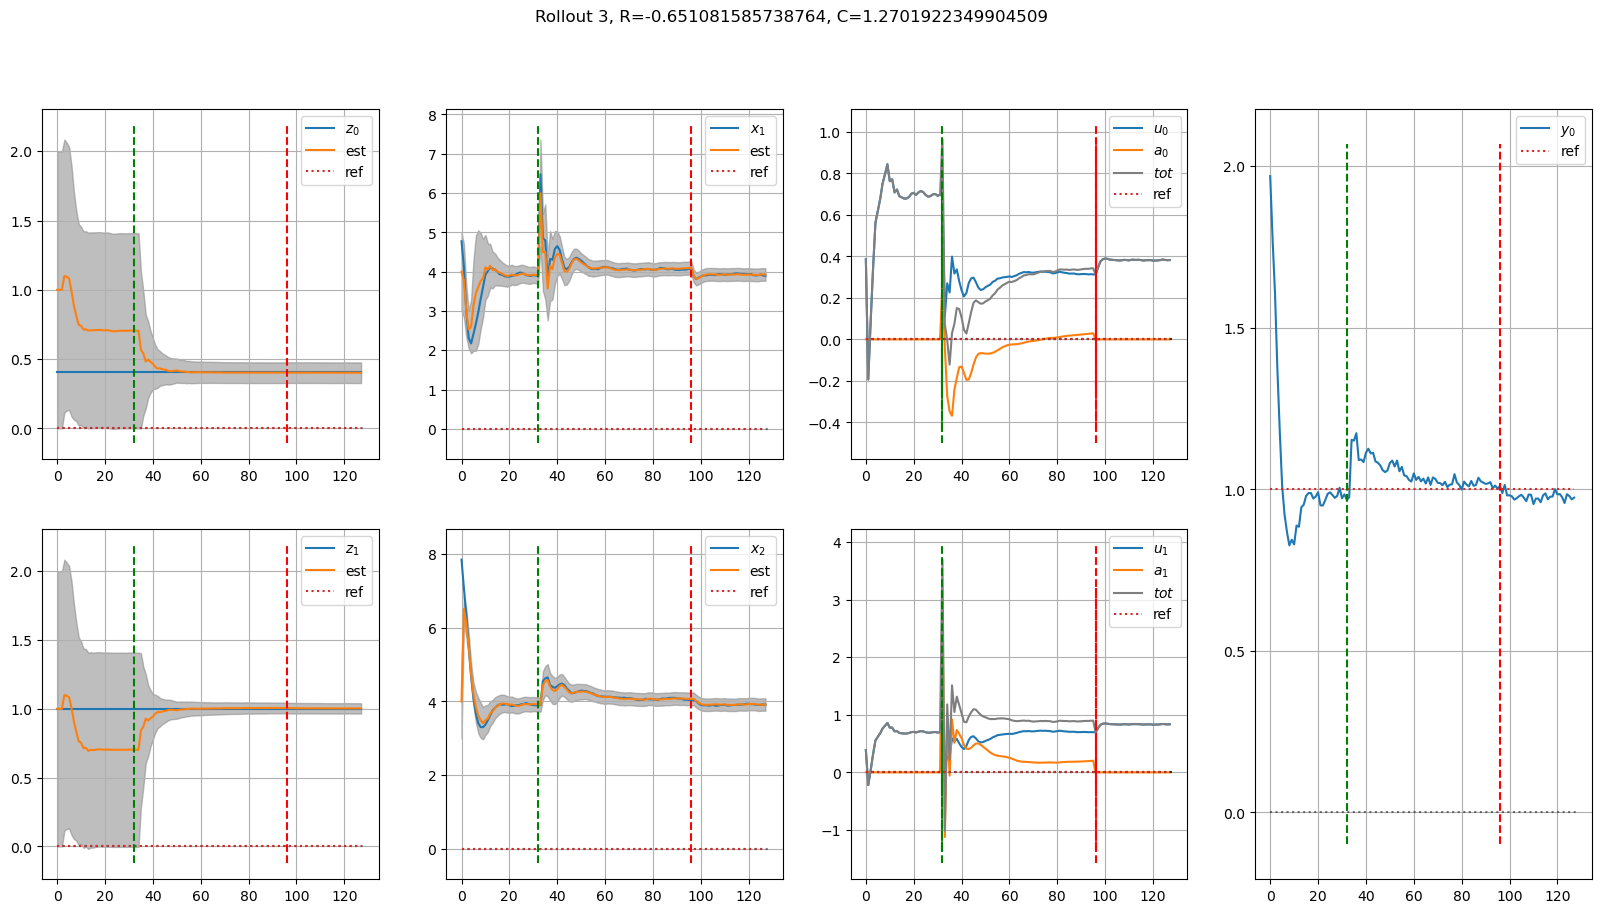

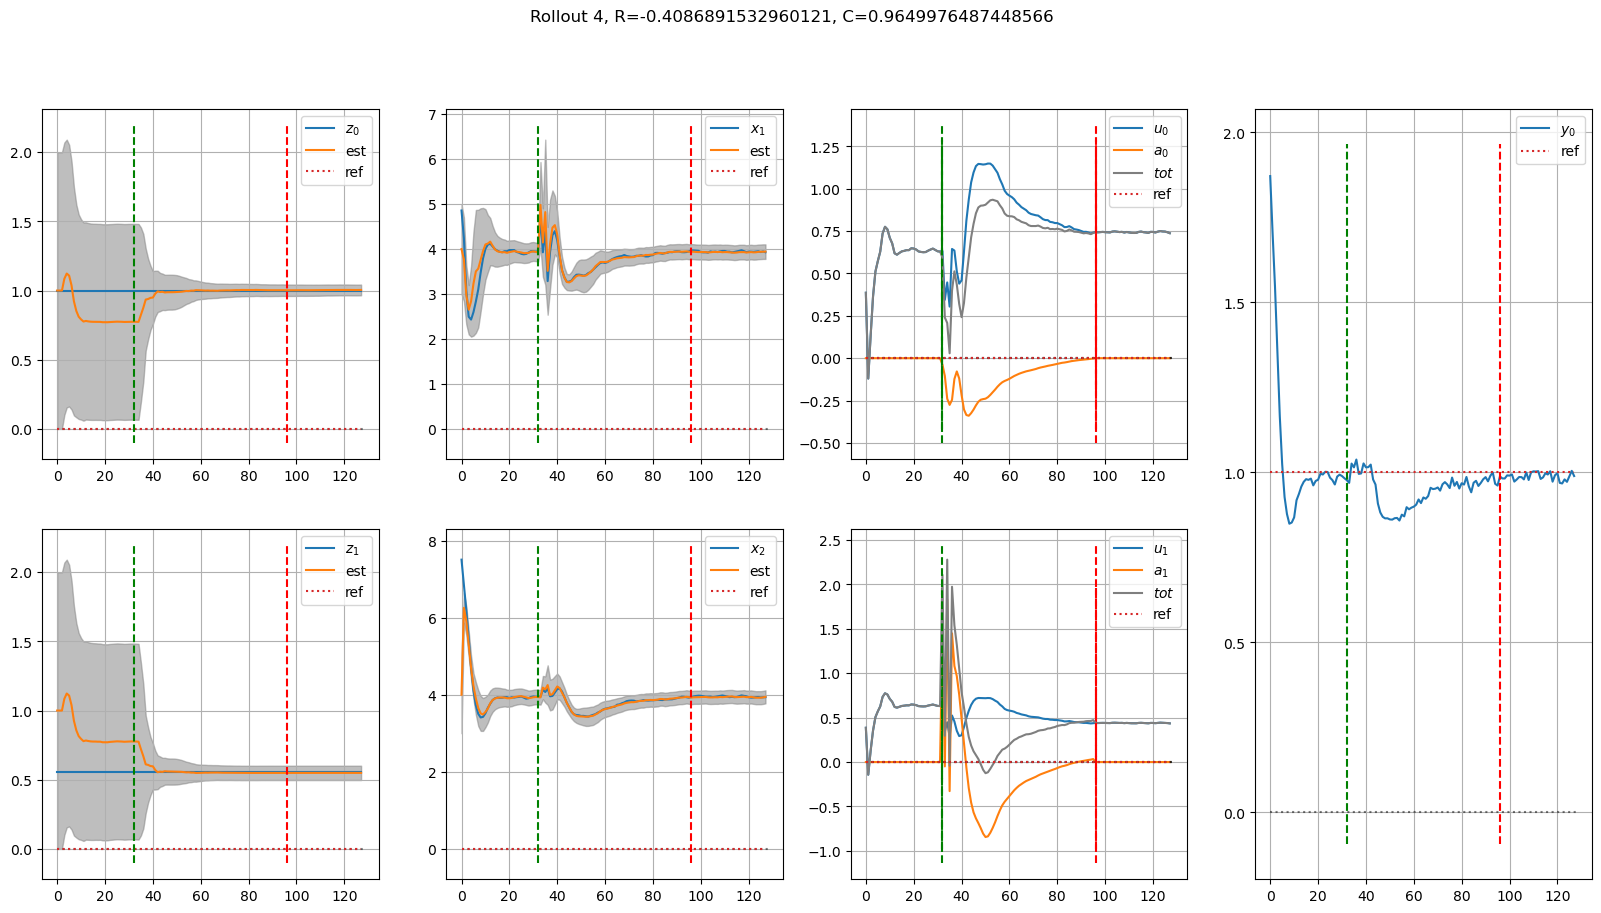

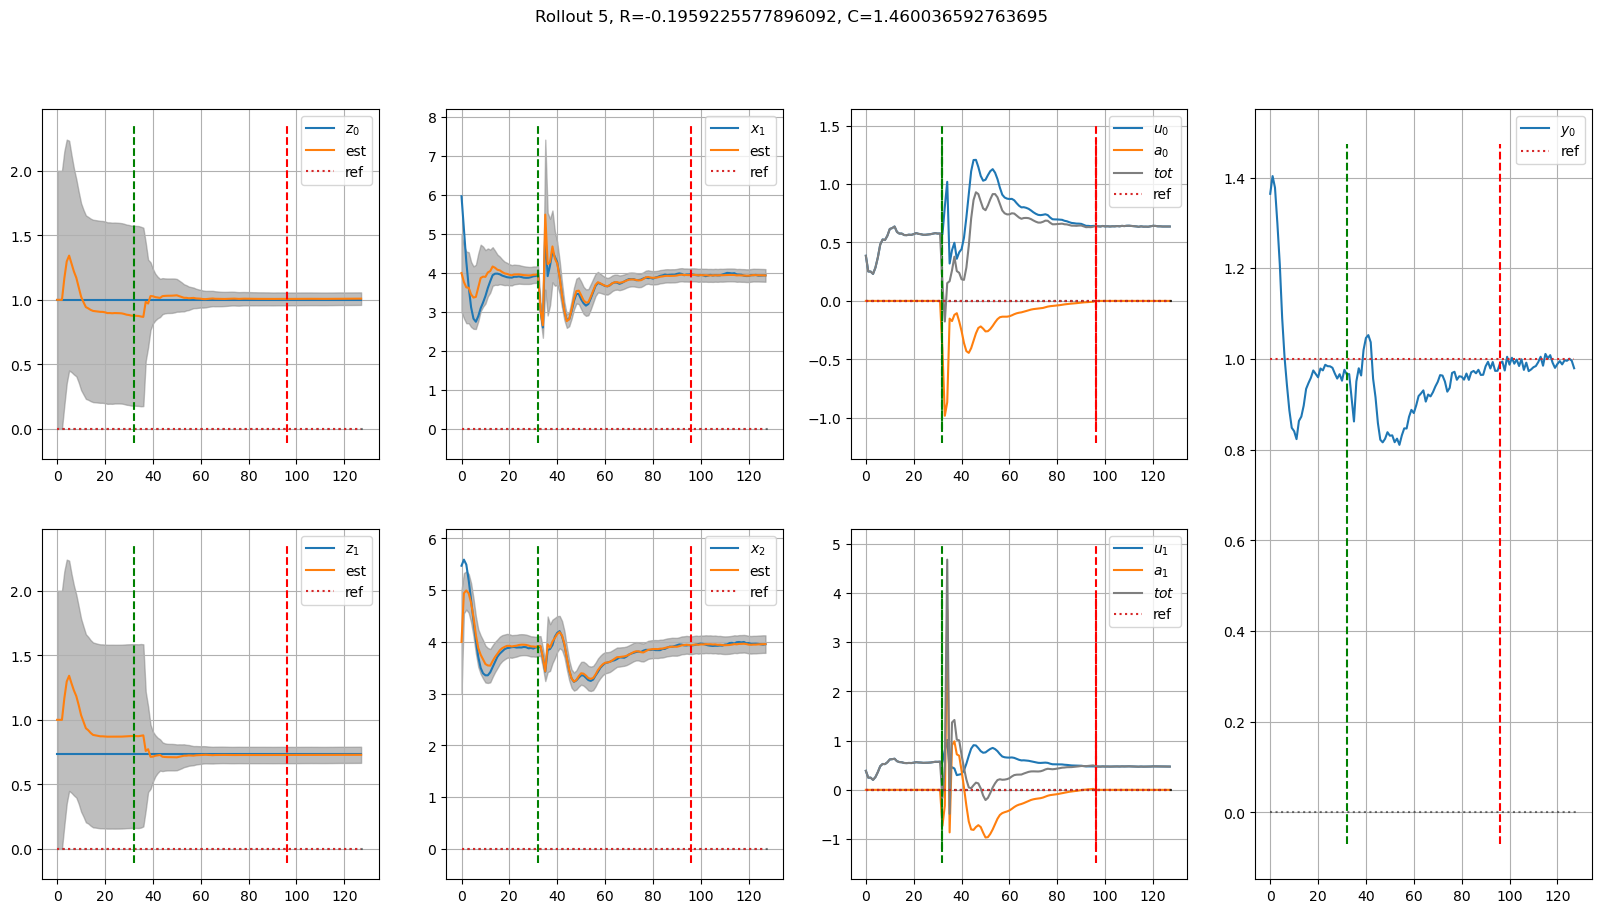

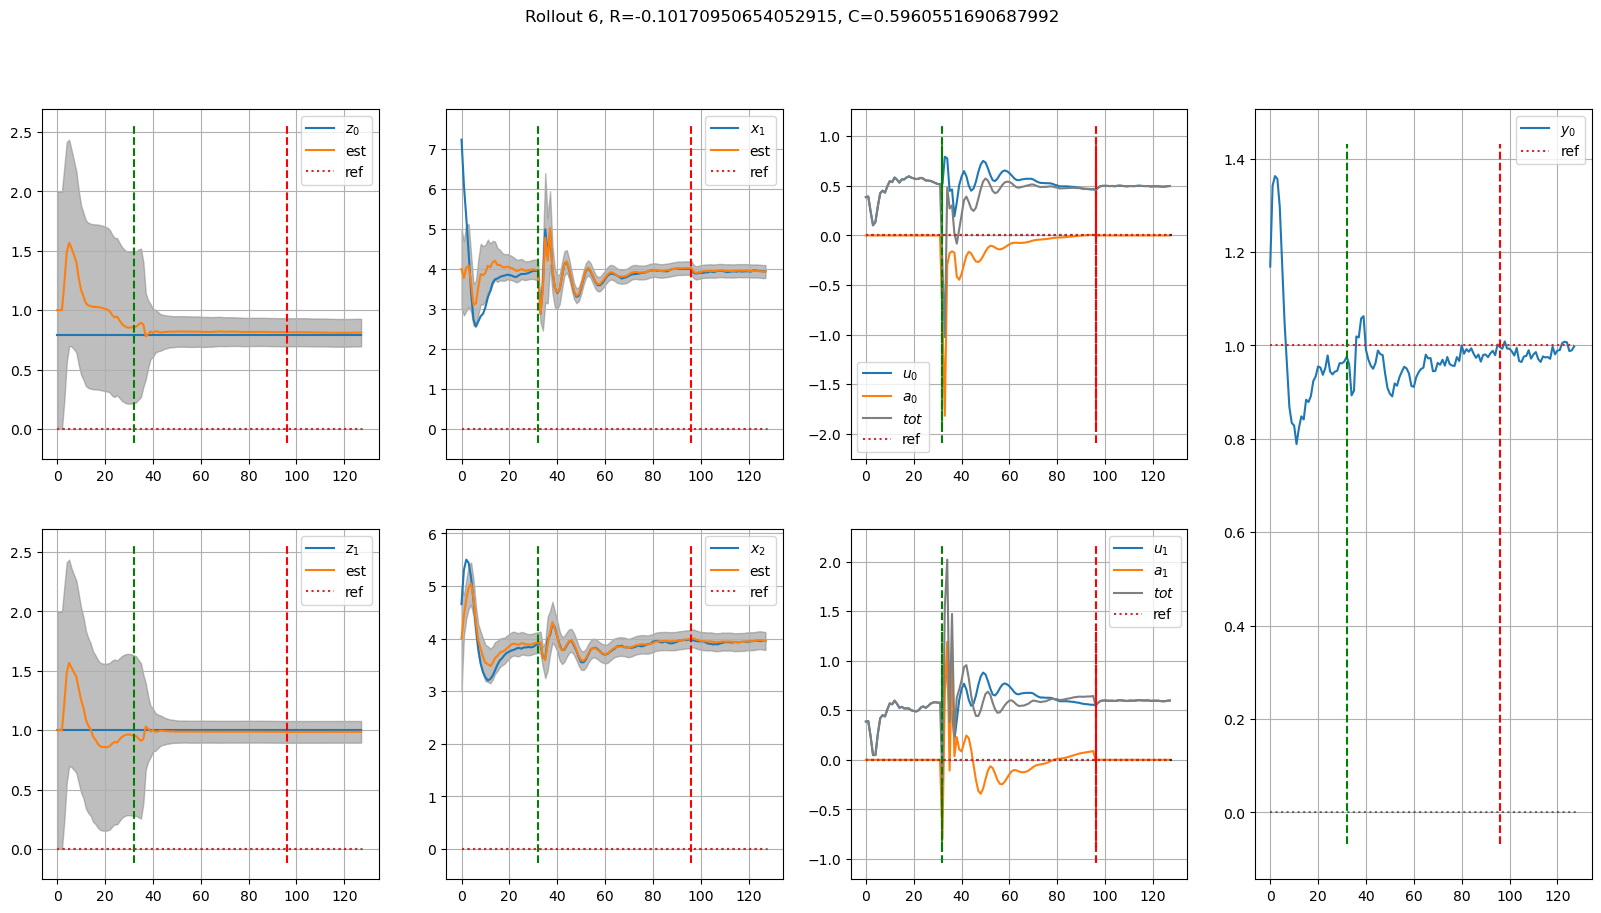

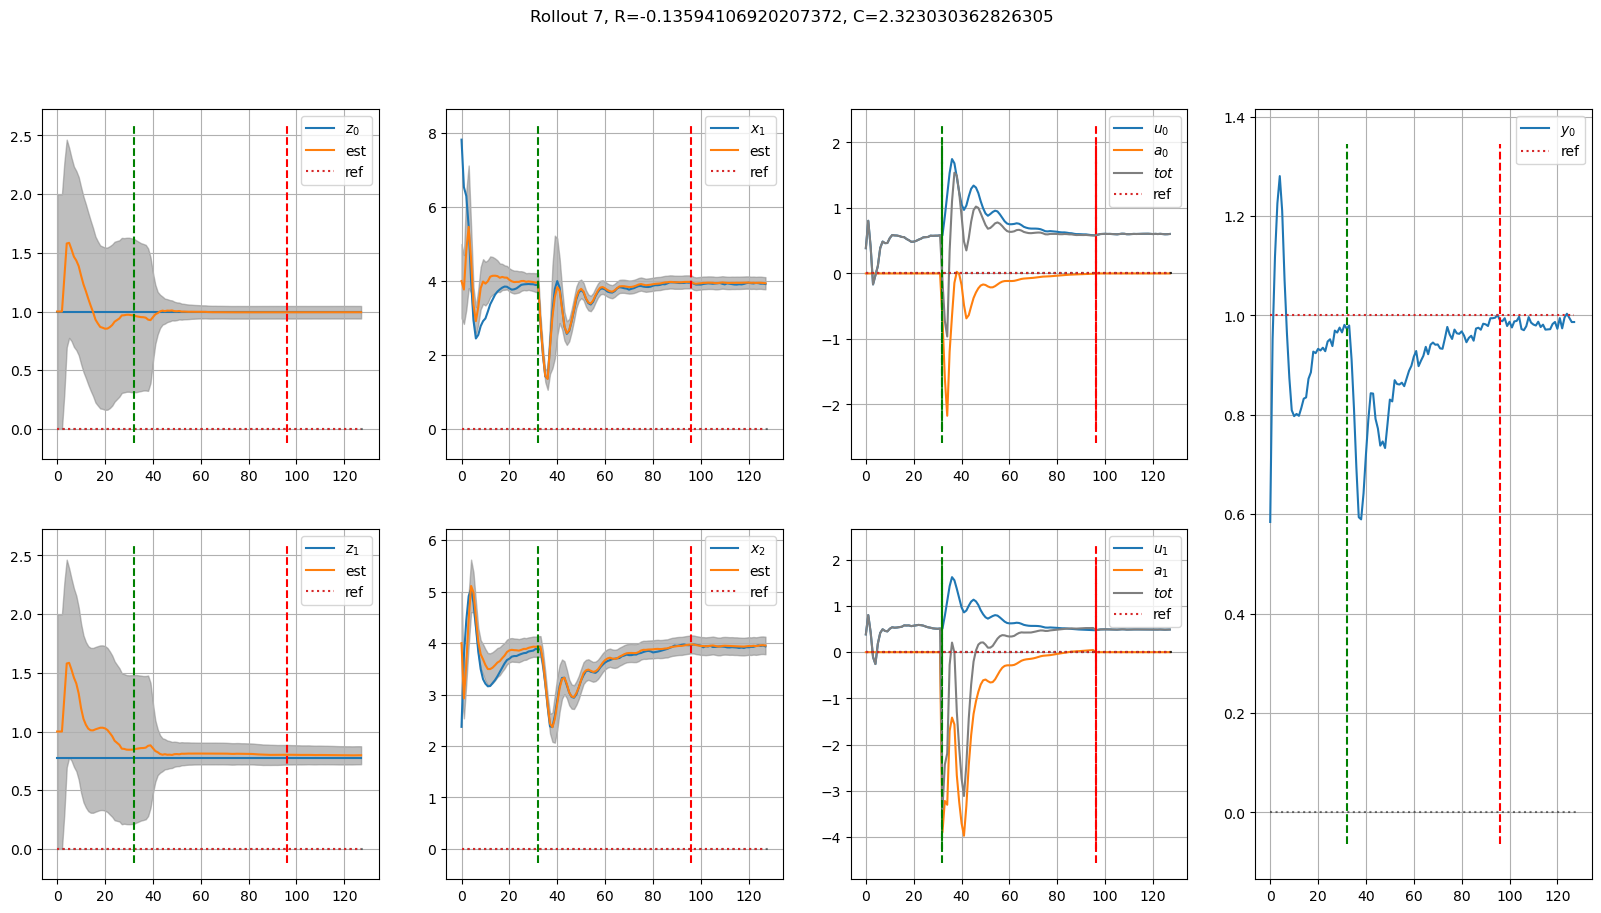

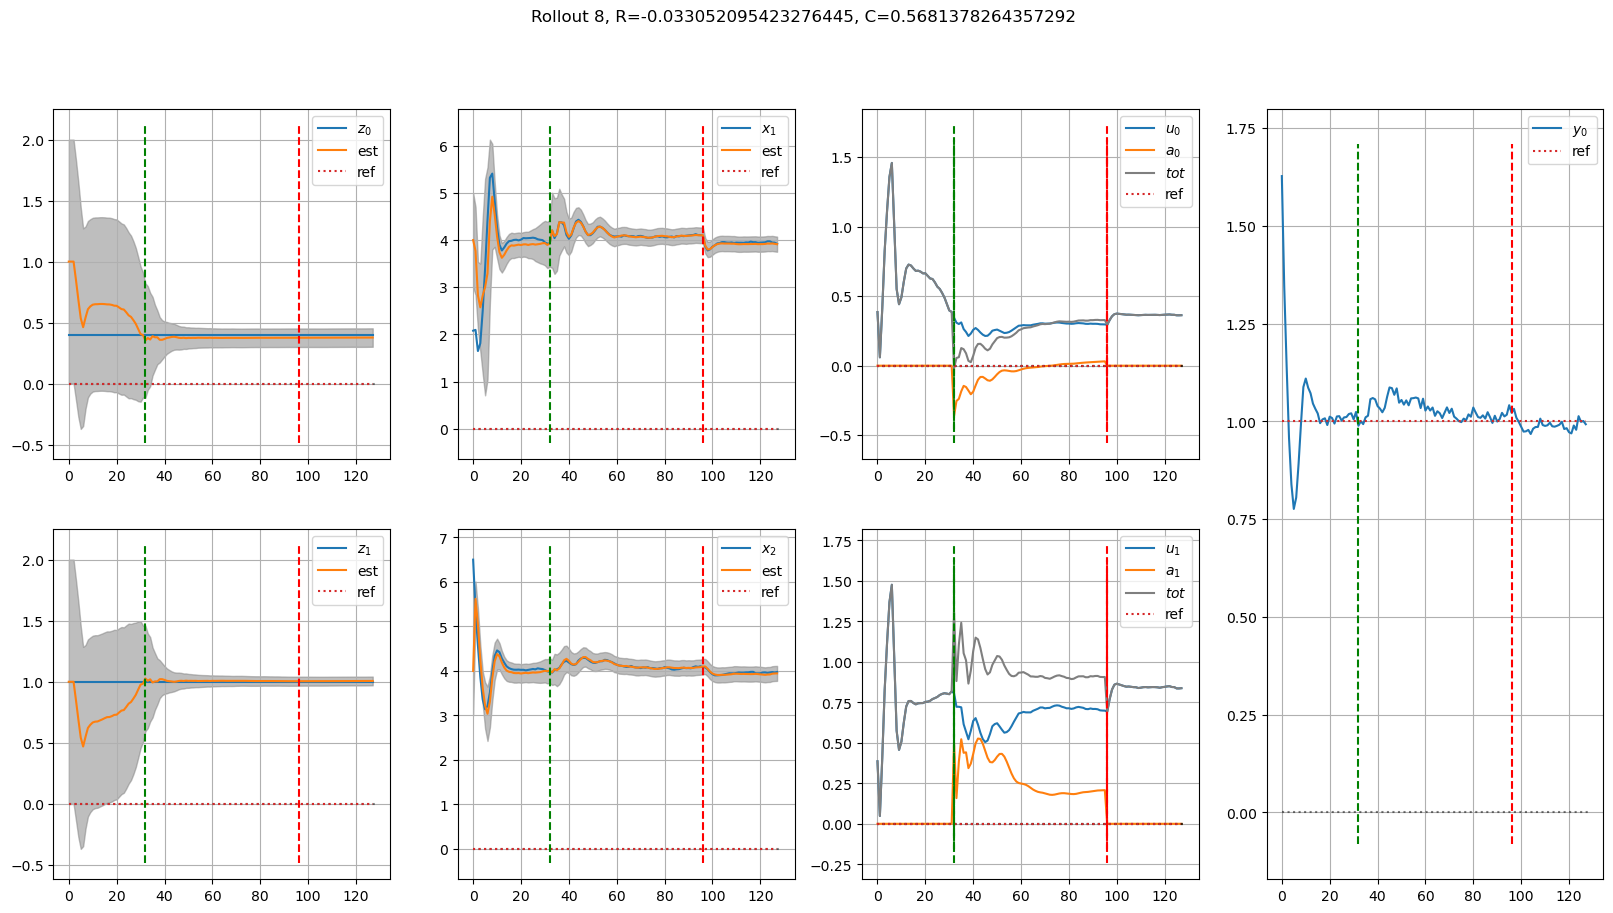

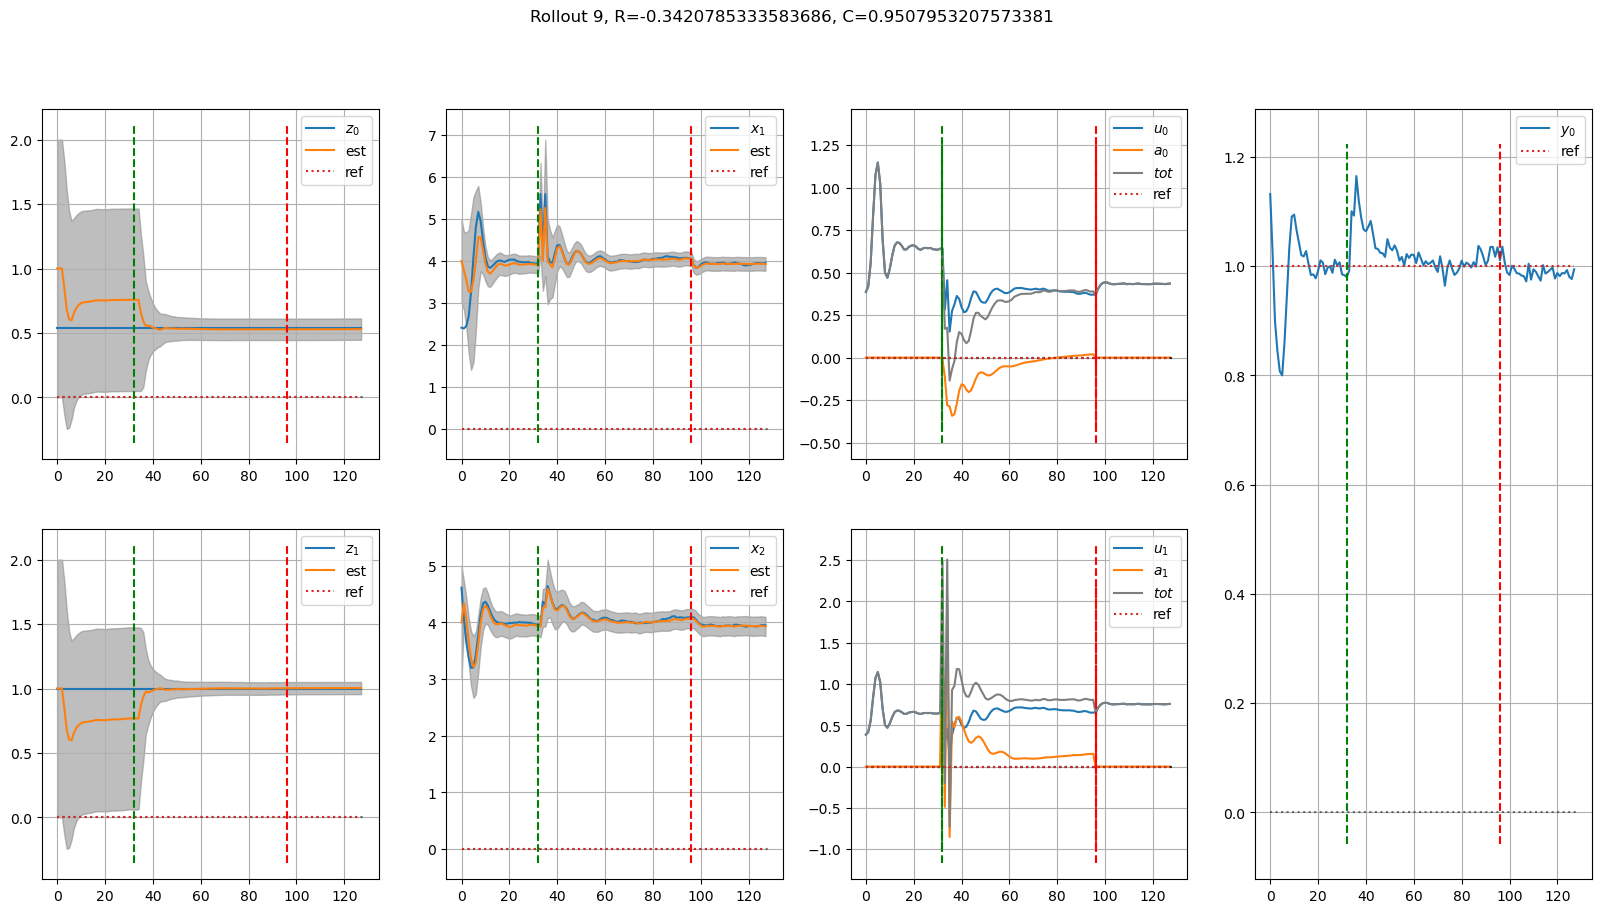

In [8]:
trainer.policy.std.value *= 1e-20
for i in range(10):
    rollout, out = env.rollout(trainer.policy, 128)
    R, _ = get_returns(rollout.r, trainer.discount)
    C, _ = get_returns(rollout.c, trainer.discount)
    env.render(out, title=f"Rollout {i}, R={R}, C={C}")